In [1]:
library(Seurat)
library(yaml)
library(dplyr)
library(stringr)
library(cowplot)
library(ggplot2)

options(repr.plot.width = 12, repr.plot.height = 7.5, repr.plot.res = 200)
options(warn = -1)

yaml_path <- "ovary_markers.yaml"
rds_path <- "roi_1/roi_1_seurat_downsampled.RDS"

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
seurat <- readRDS(rds_path)
seurat

An object of class Seurat 
6405 features across 2049 samples within 5 assays 
Active assay: Xenium (5101 features, 0 variable features)
 1 layer present: counts
 4 other assays present: BlankCodeword, ControlCodeword, ControlProbe, GenomicControl
 2 dimensional reductions calculated: xenium_pca, xenium_umap
 1 spatial field of view present: fov

In [3]:
marker_list <- yaml::read_yaml(file = yaml_path)
marker_list <- lapply(marker_list$cell_types, '[[', "markers")
marker_list <- lapply(marker_list, unlist)
marker_list <- lapply(marker_list, str_to_upper)

In [4]:
seurat <- AddModuleScore(object = seurat, features = marker_list, assay = "Xenium", slot = "counts", name = "CellTypeScore")

In [5]:
score_cols <- grep("^CellTypeScore", colnames(seurat@meta.data), value = TRUE)
names(score_cols) <- names(marker_list)

for (i in seq_along(score_cols)){
    colnames(seurat@meta.data)[
        colnames(seurat@meta.data) == score_cols[i]
    ] <- paste0(names(score_cols)[i], "_score")
}

In [6]:
seurat@meta.data |>
    select(xenium_clusters, ends_with("_score")) |>
    group_by(xenium_clusters) |>
    summarize(across(everything(), mean)) ->
    cluster_scores

In [7]:
cluster_scores |>
    rowwise() |>
    mutate(
        max_score = max(c_across(ends_with("_score"))),
        predicted_celltype = ifelse(
            max_score > 0.3,
            names(across(ends_with("_score")))[which.max(c_across(ends_with("_score")))],
            "Unassigned"
        )
    ) ->
    annotations

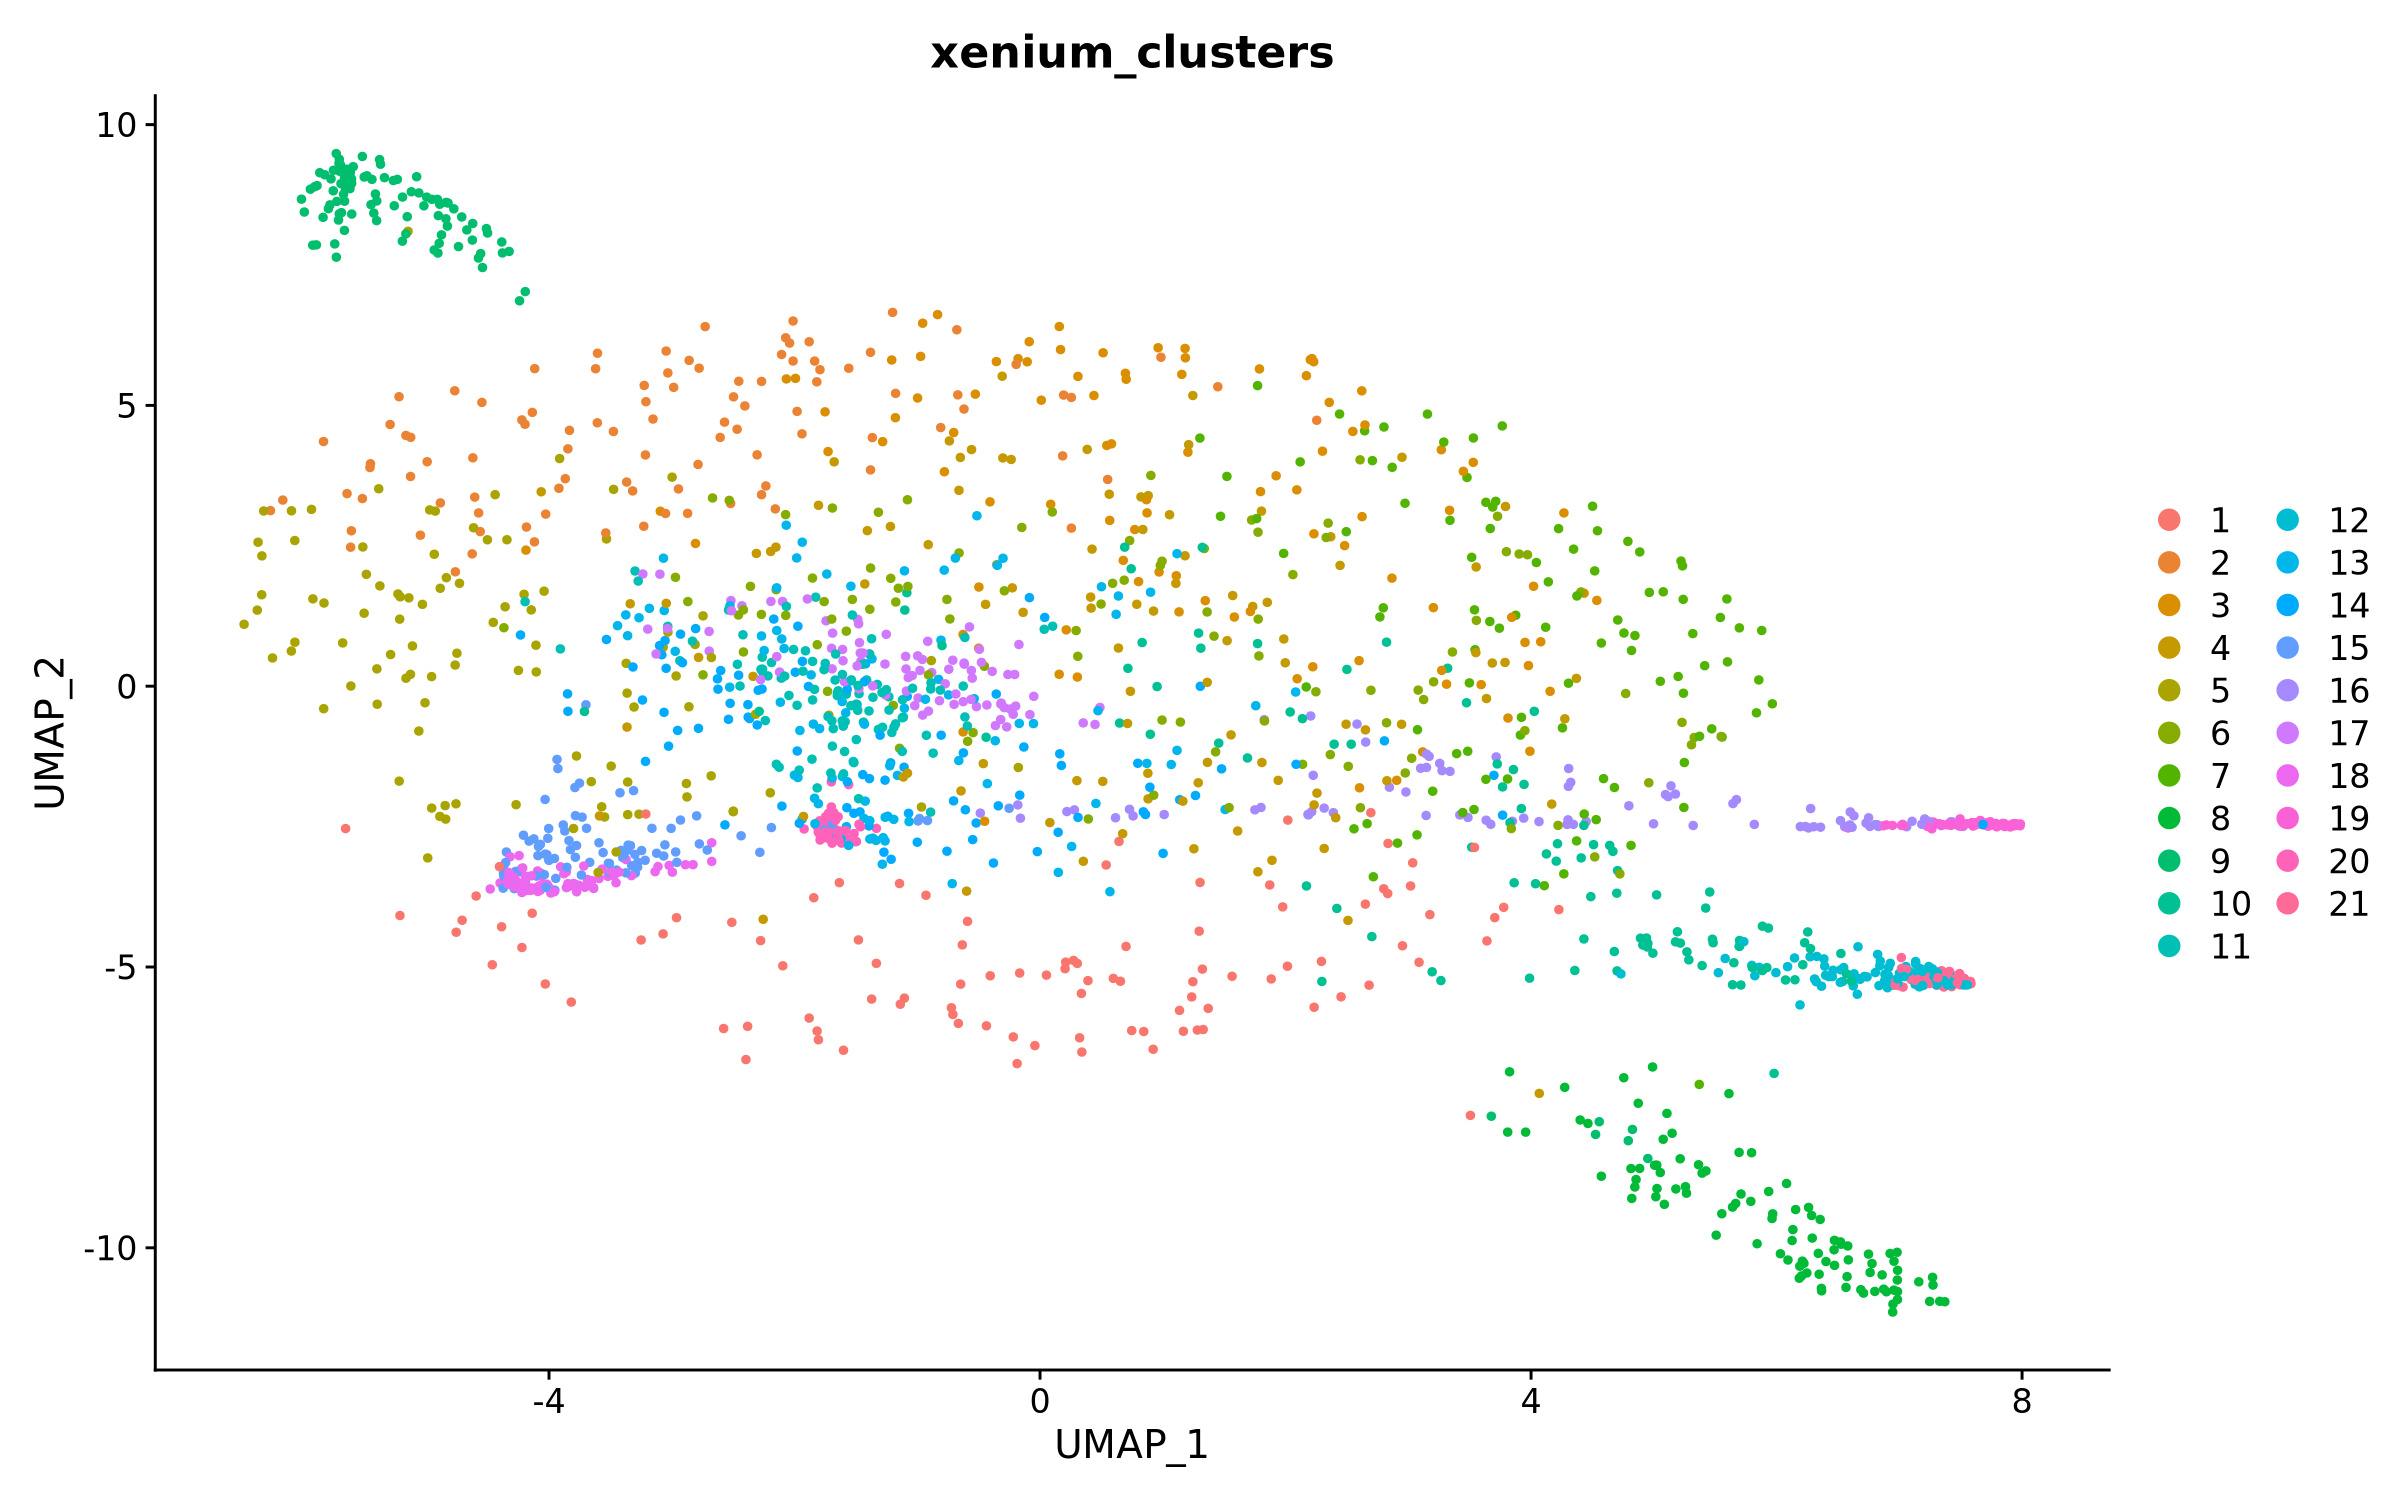

In [8]:
DimPlot(object = seurat, group.by = "xenium_clusters", reduction = "xenium_umap")

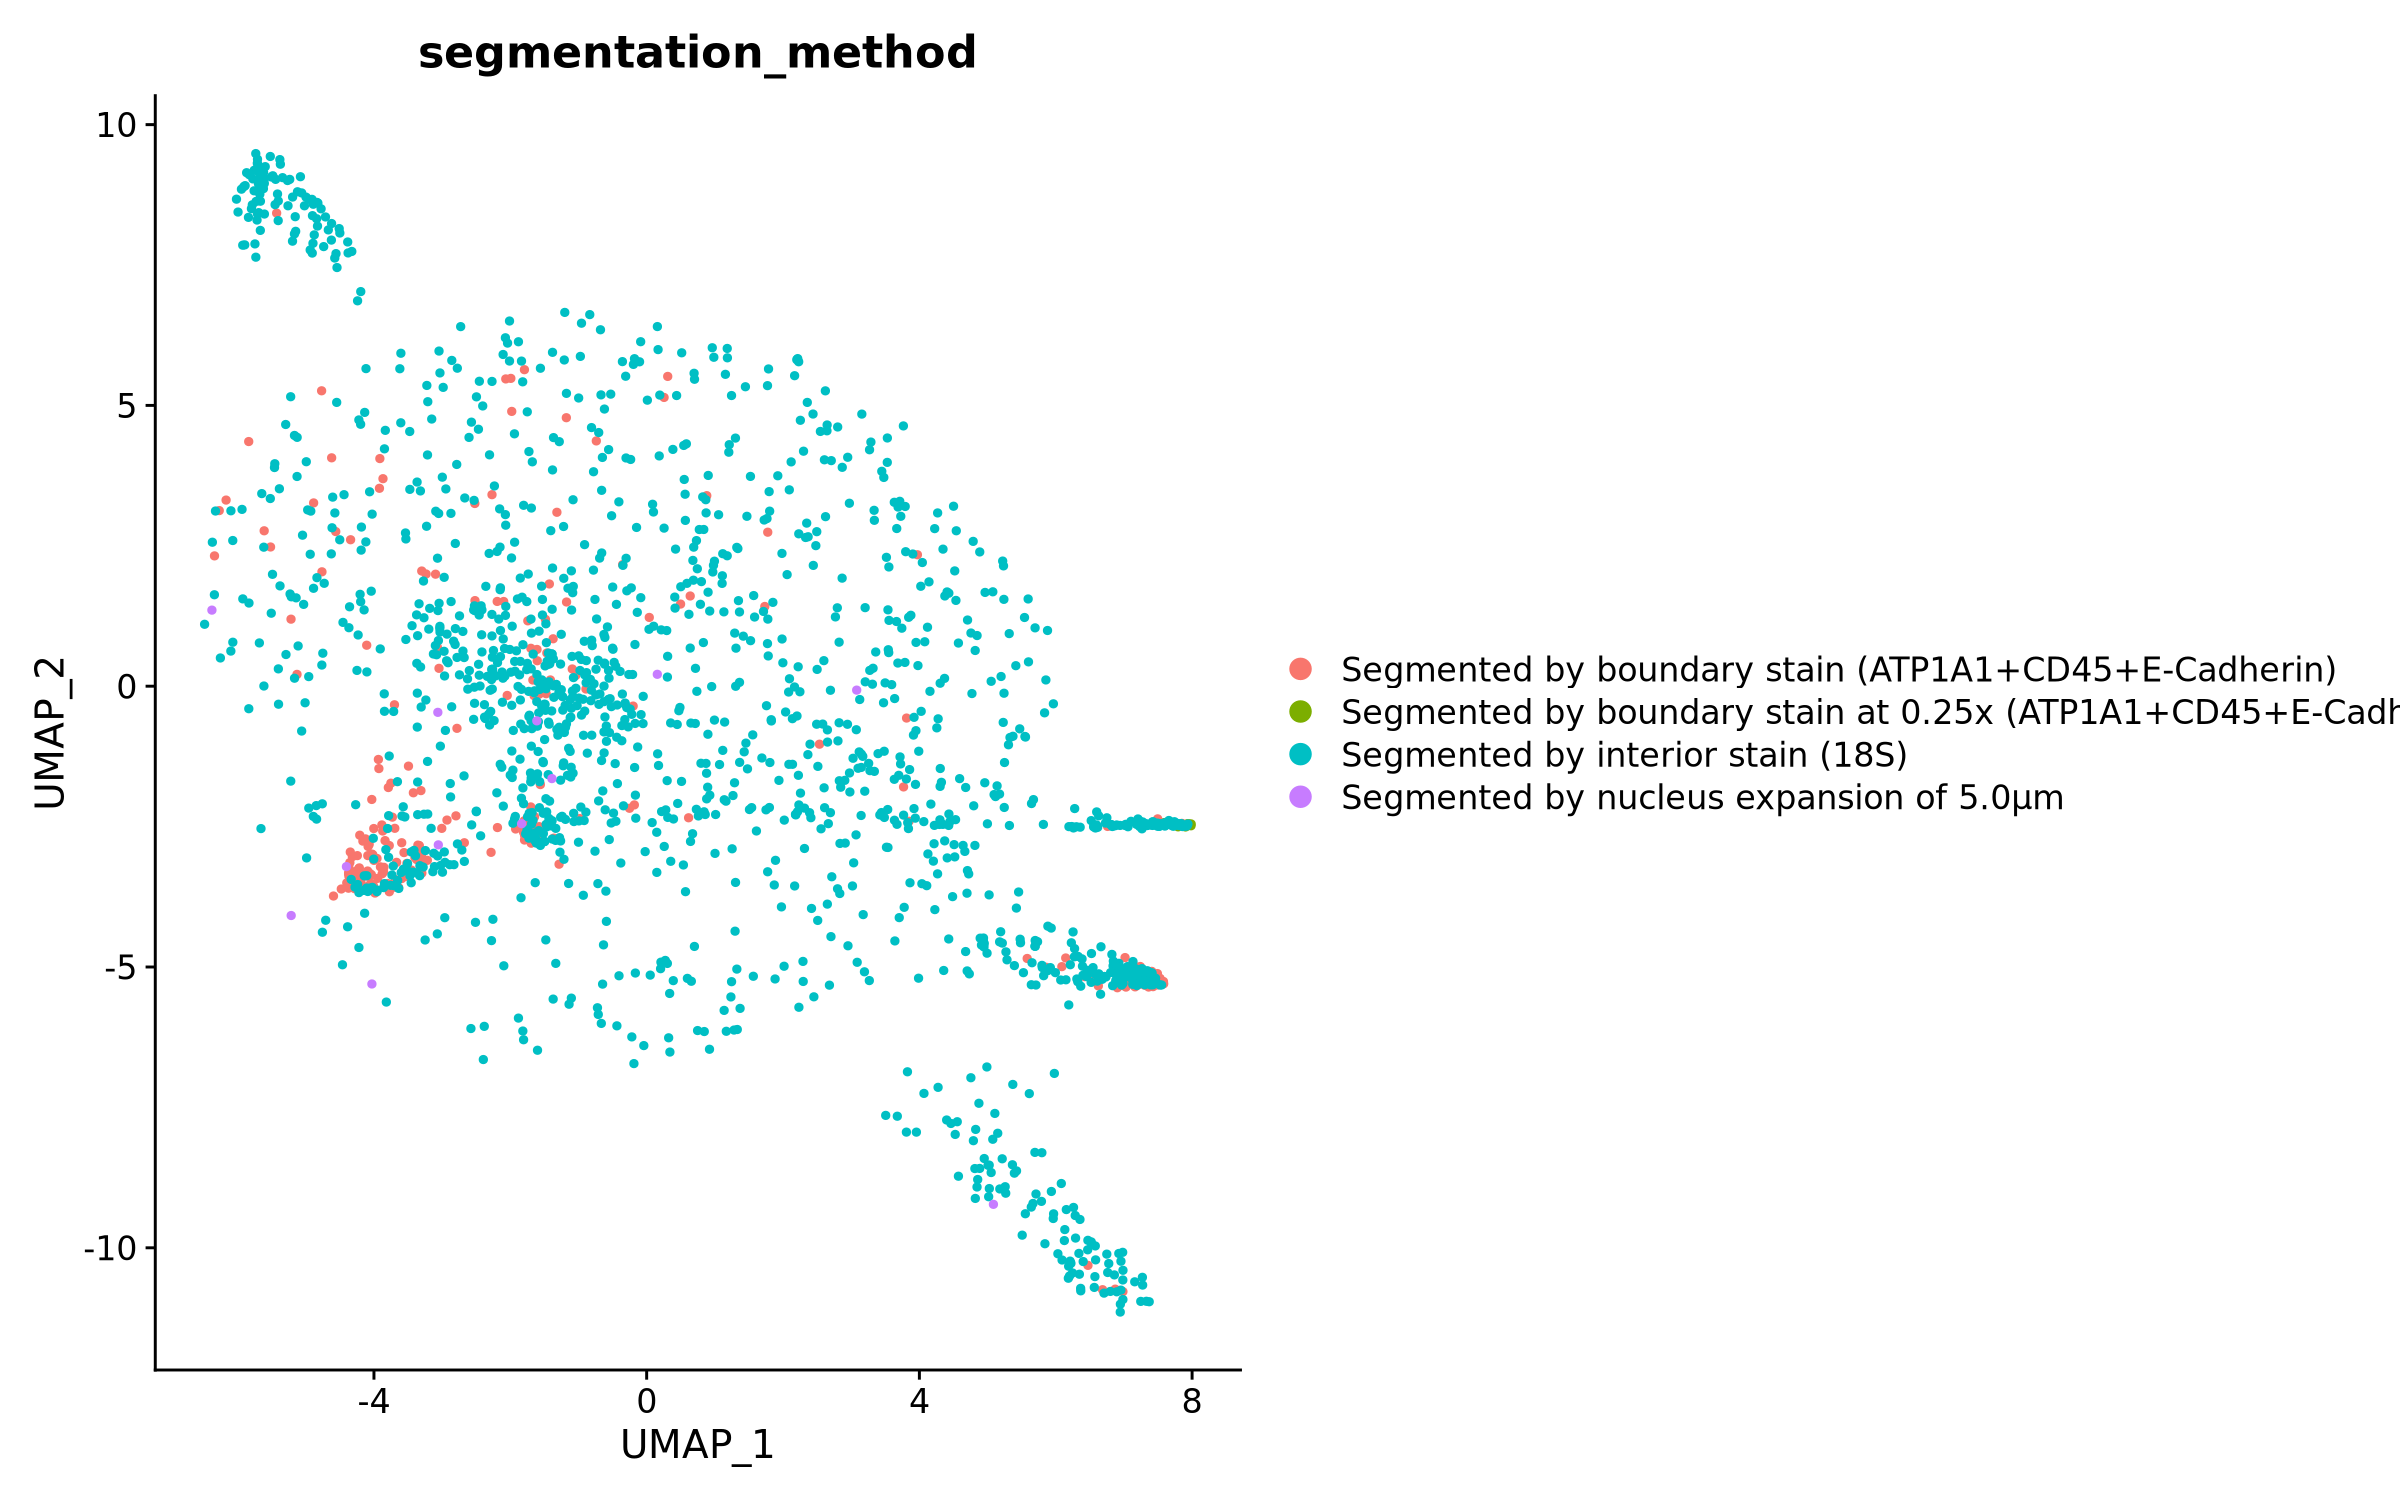

In [9]:
DimPlot(object = seurat, group.by = "segmentation_method", reduction = "xenium_umap")

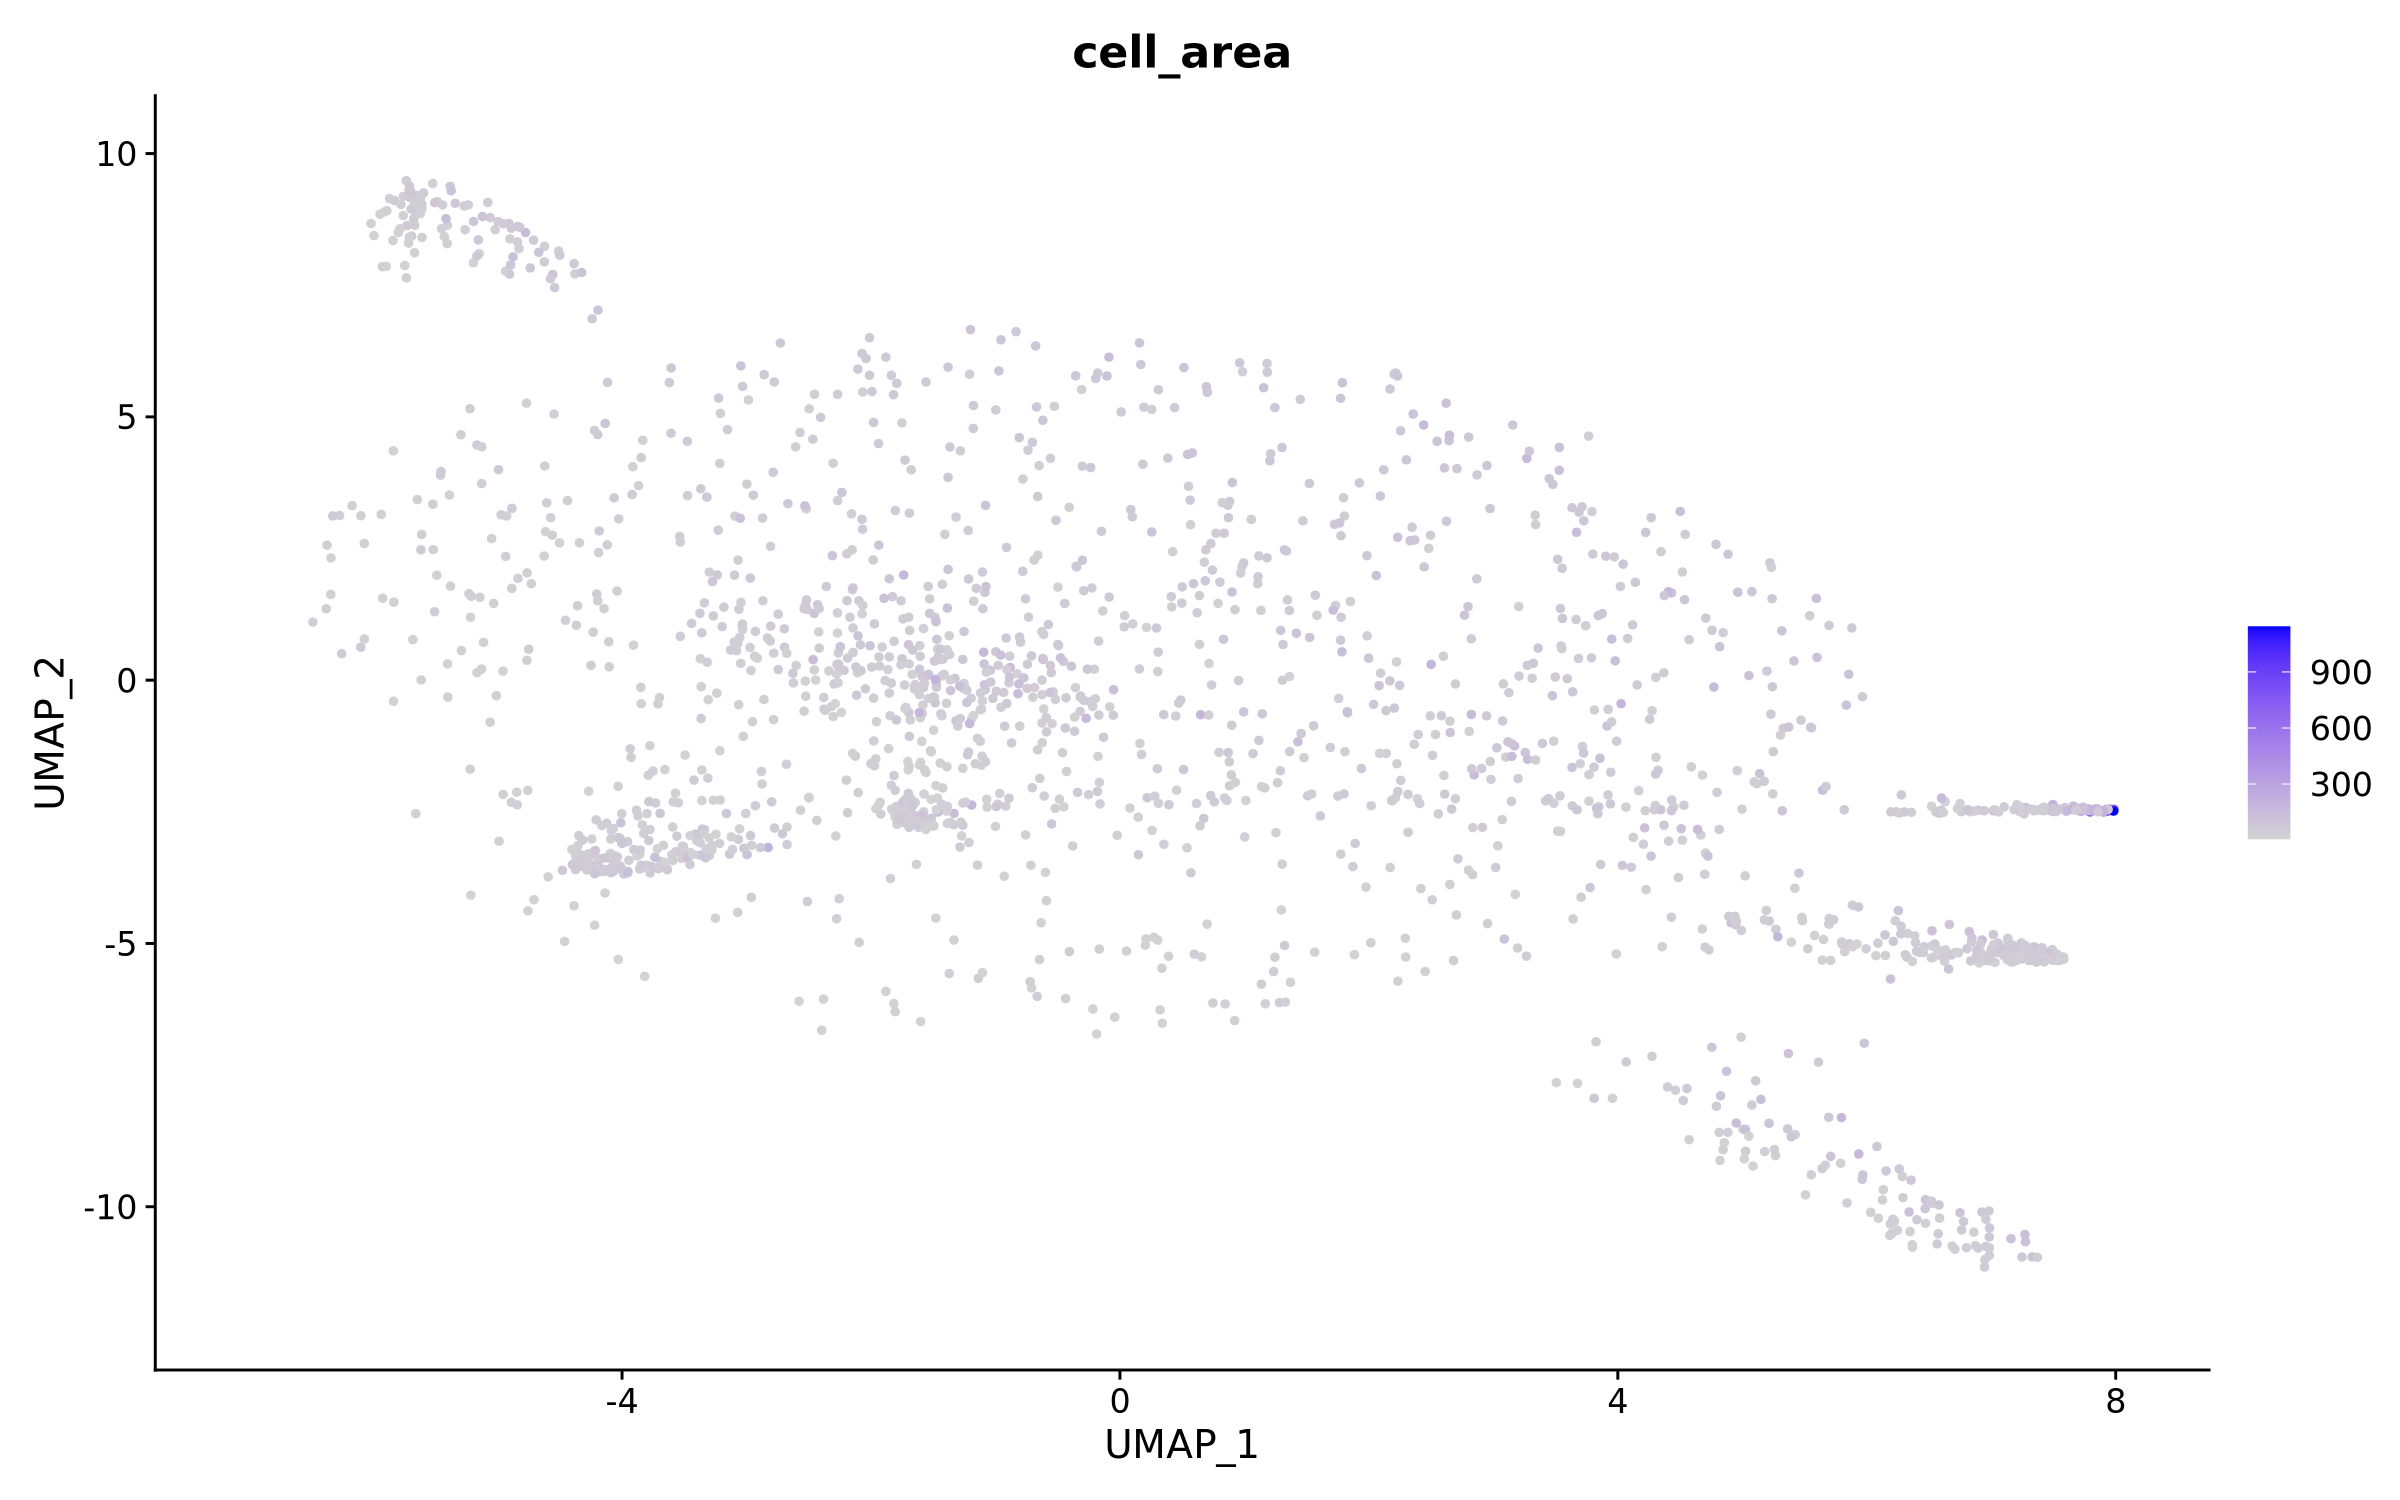

In [10]:
FeaturePlot(object = seurat, features = "cell_area", reduction = "xenium_umap")

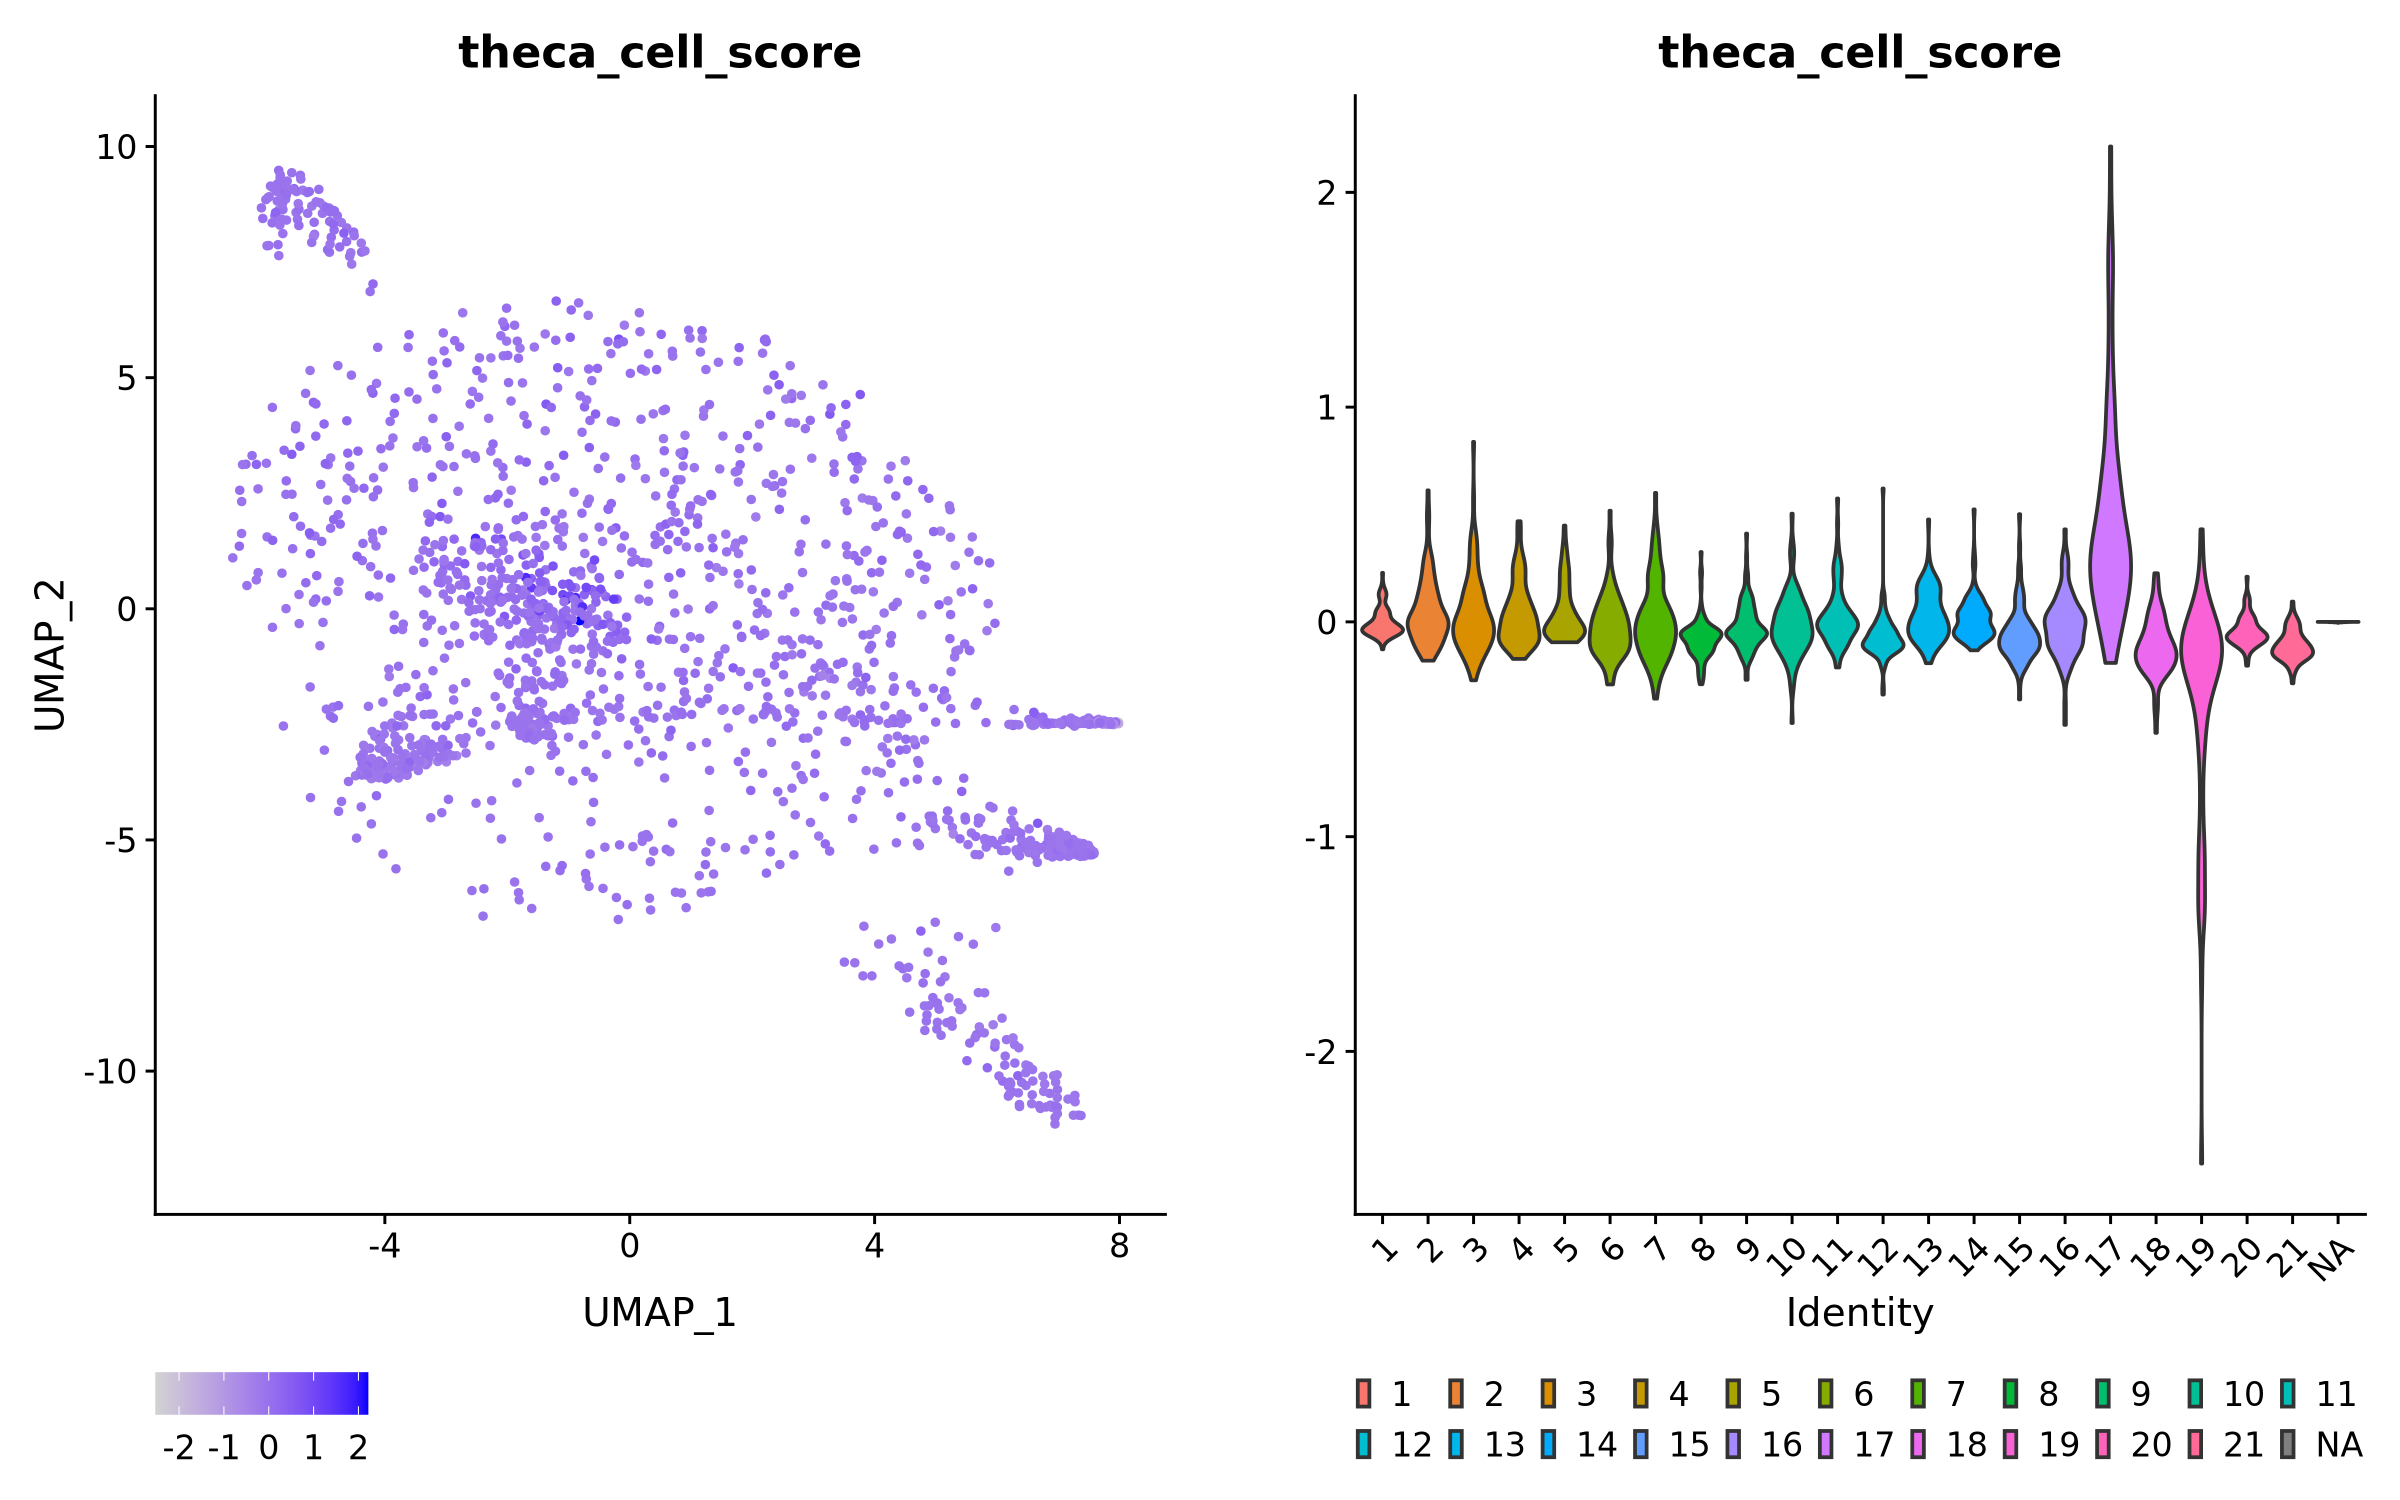

In [11]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "theca_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "theca_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

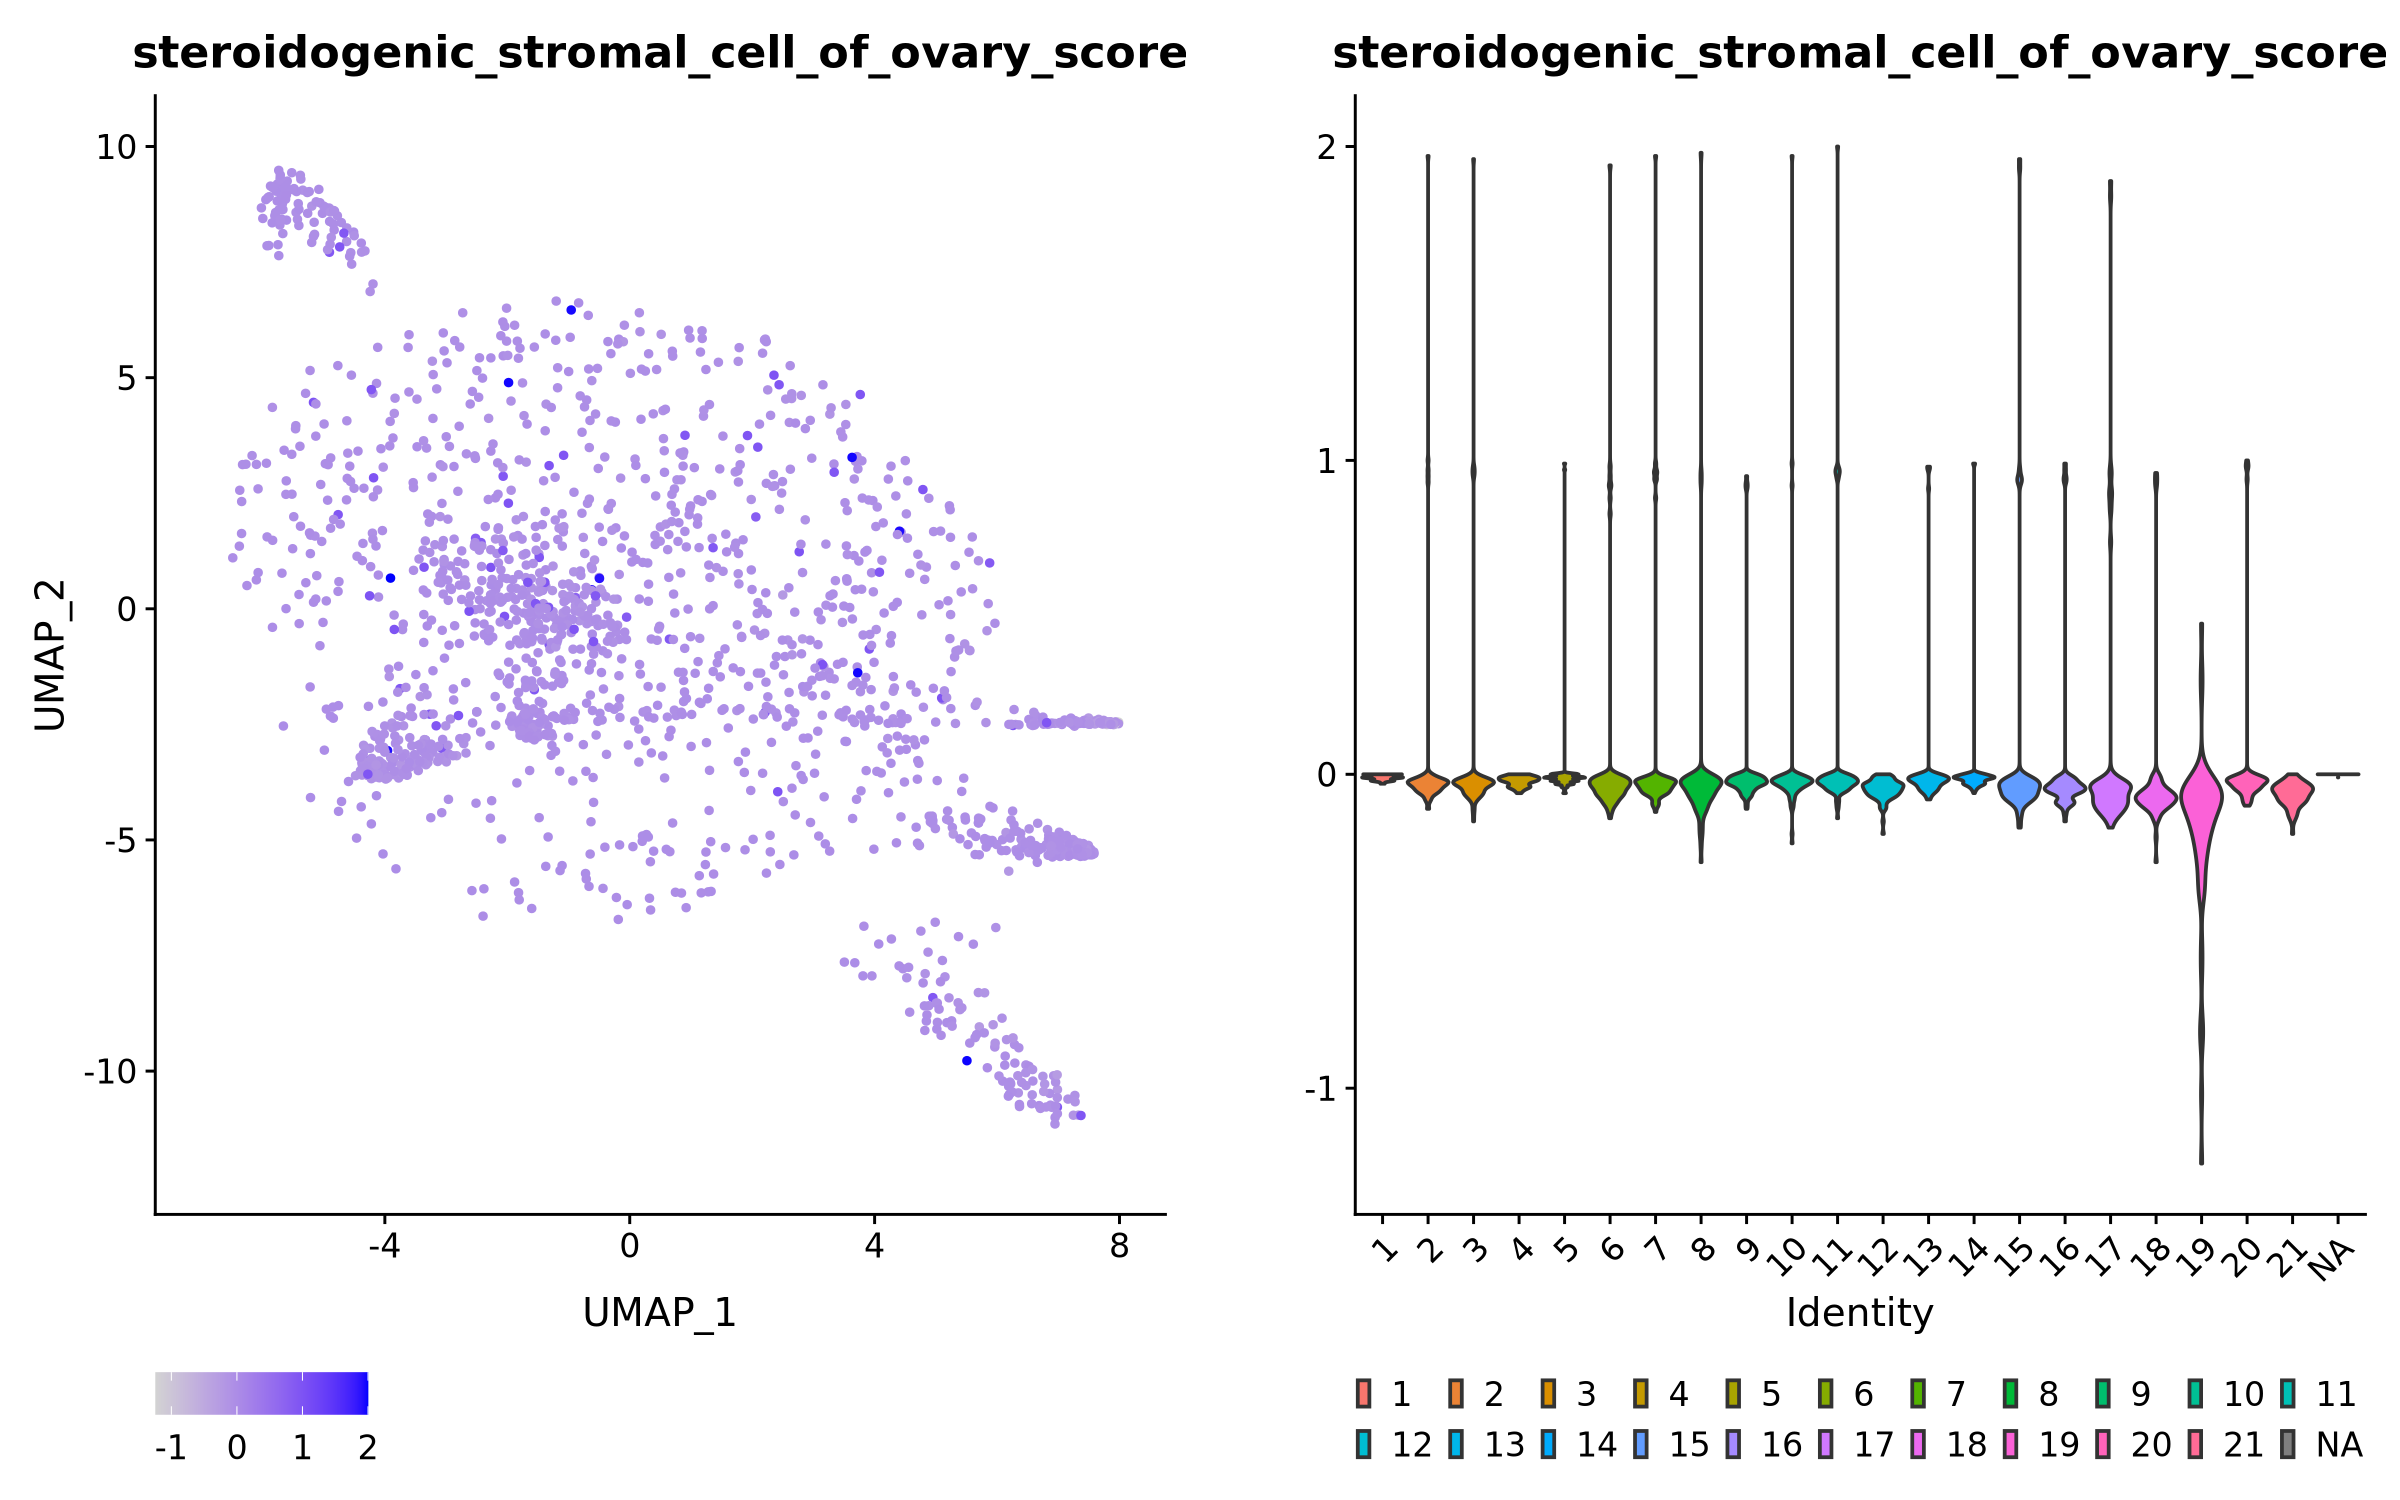

In [12]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "steroidogenic_stromal_cell_of_ovary_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "steroidogenic_stromal_cell_of_ovary_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

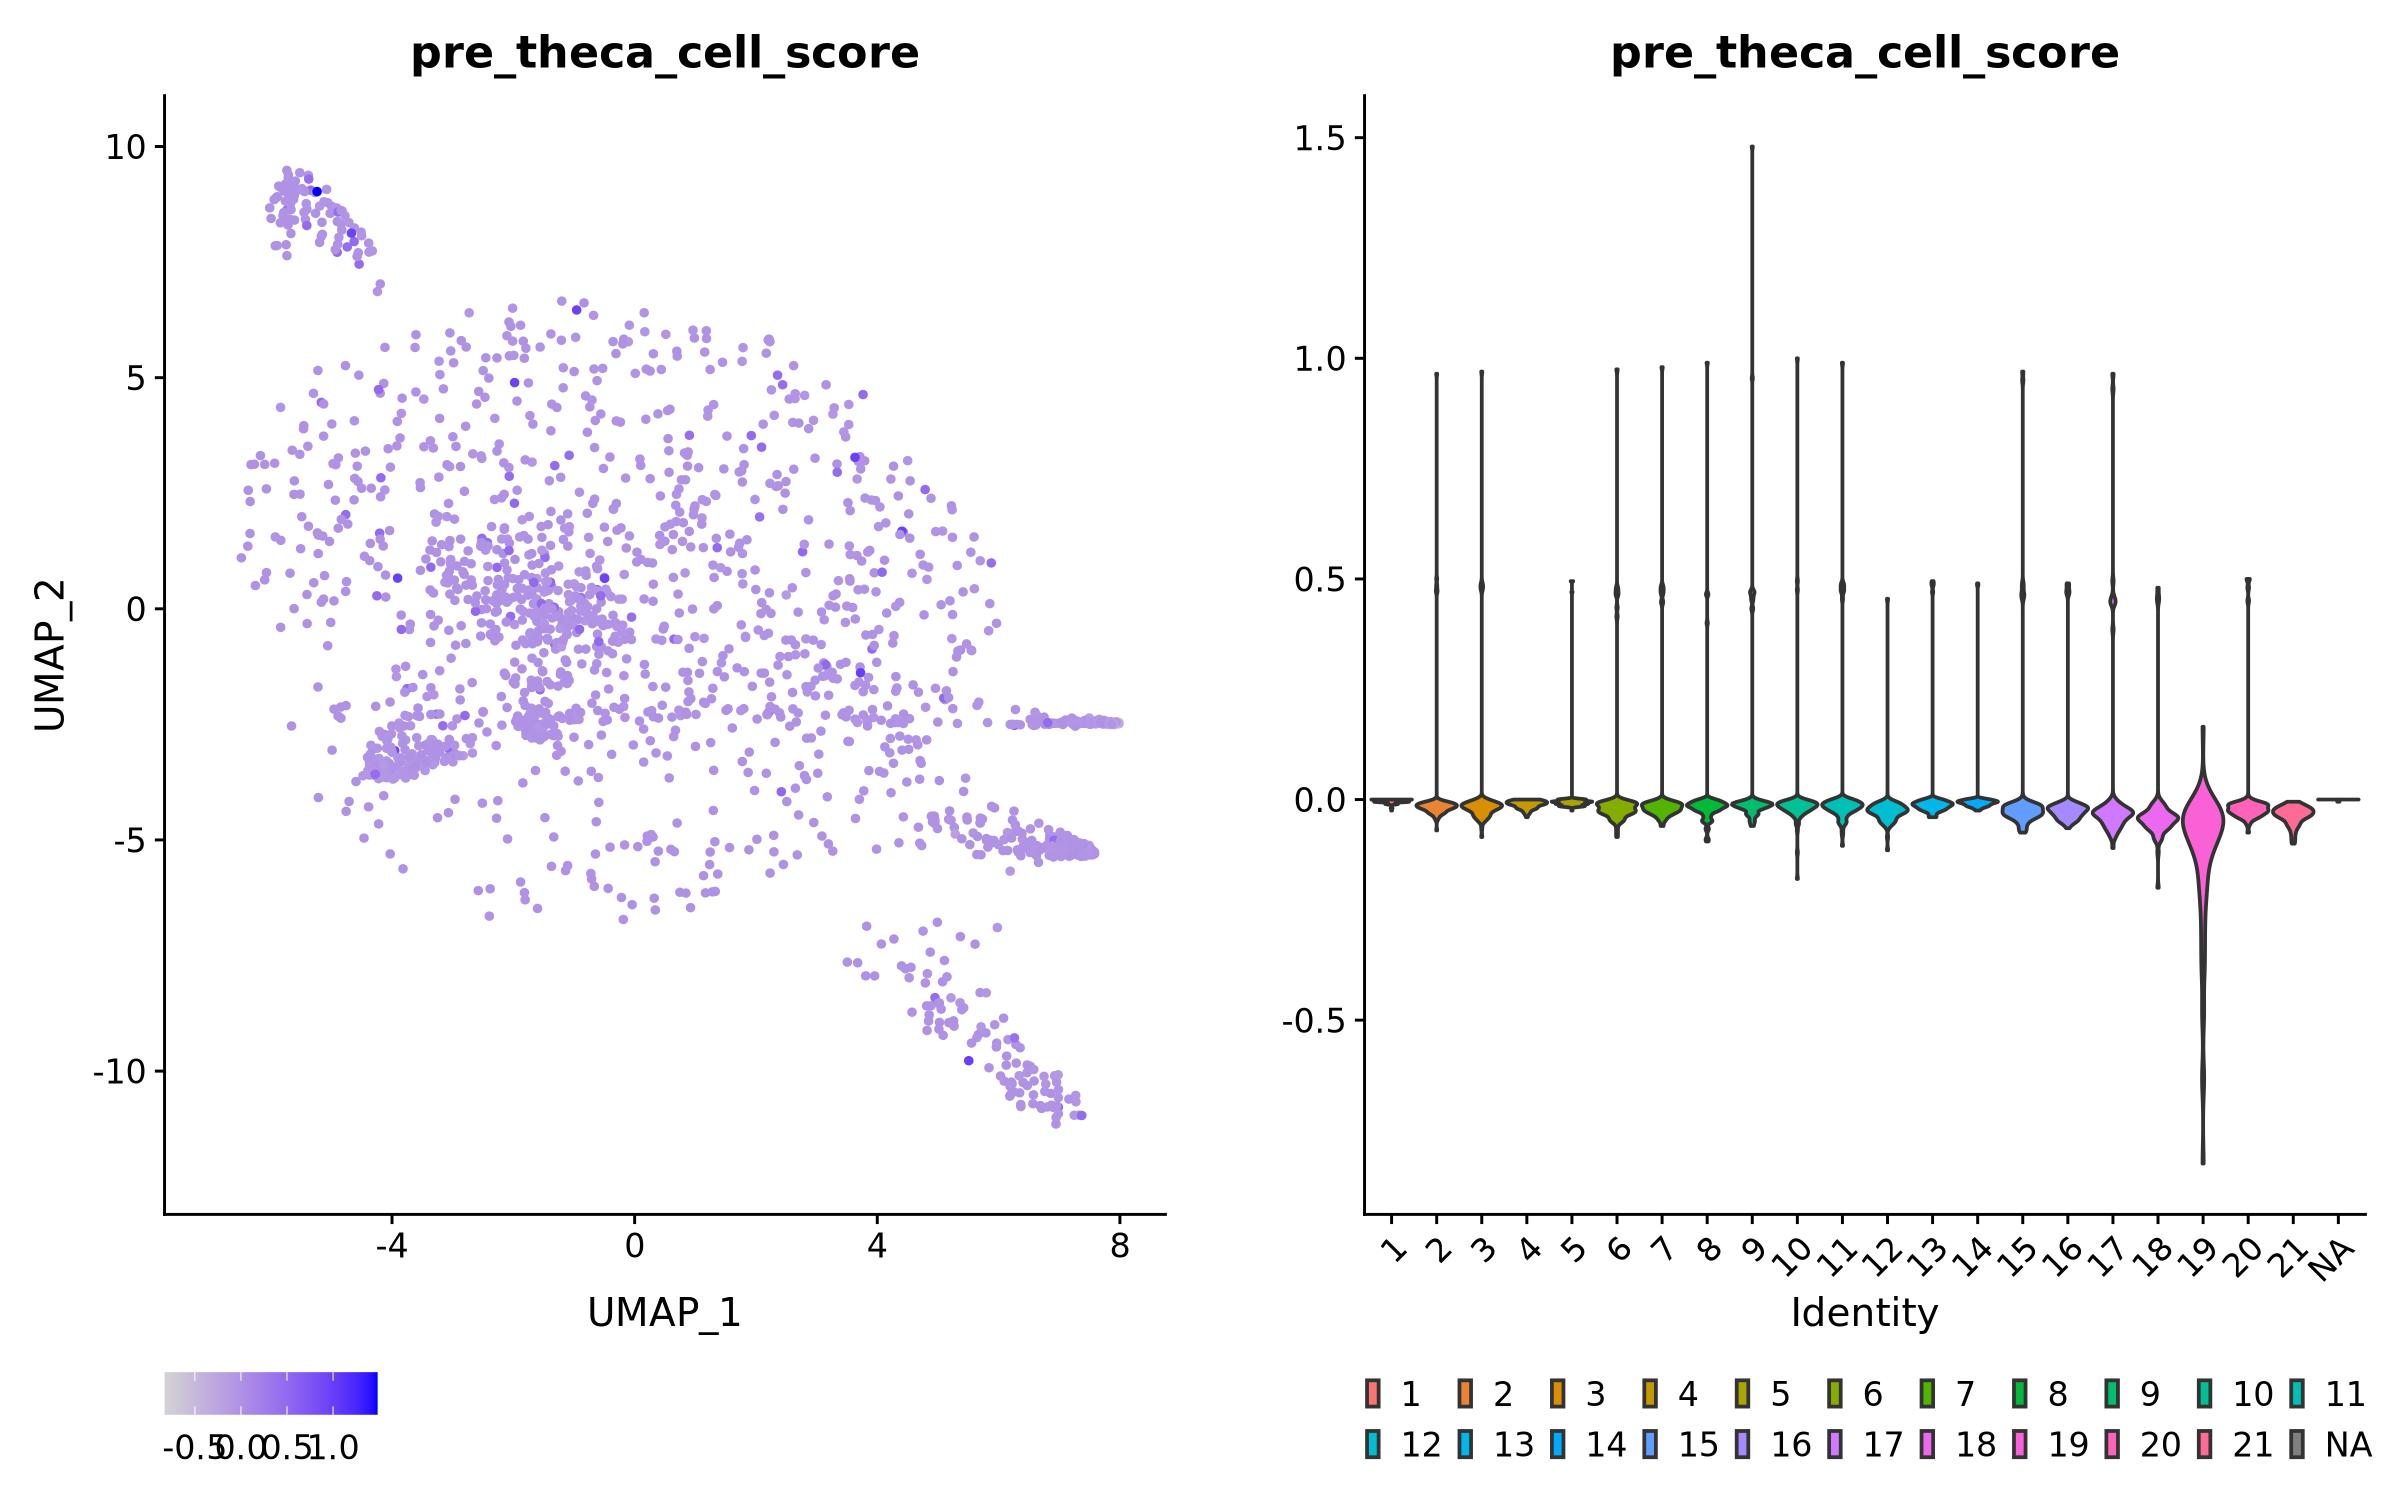

In [13]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "pre_theca_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "pre_theca_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

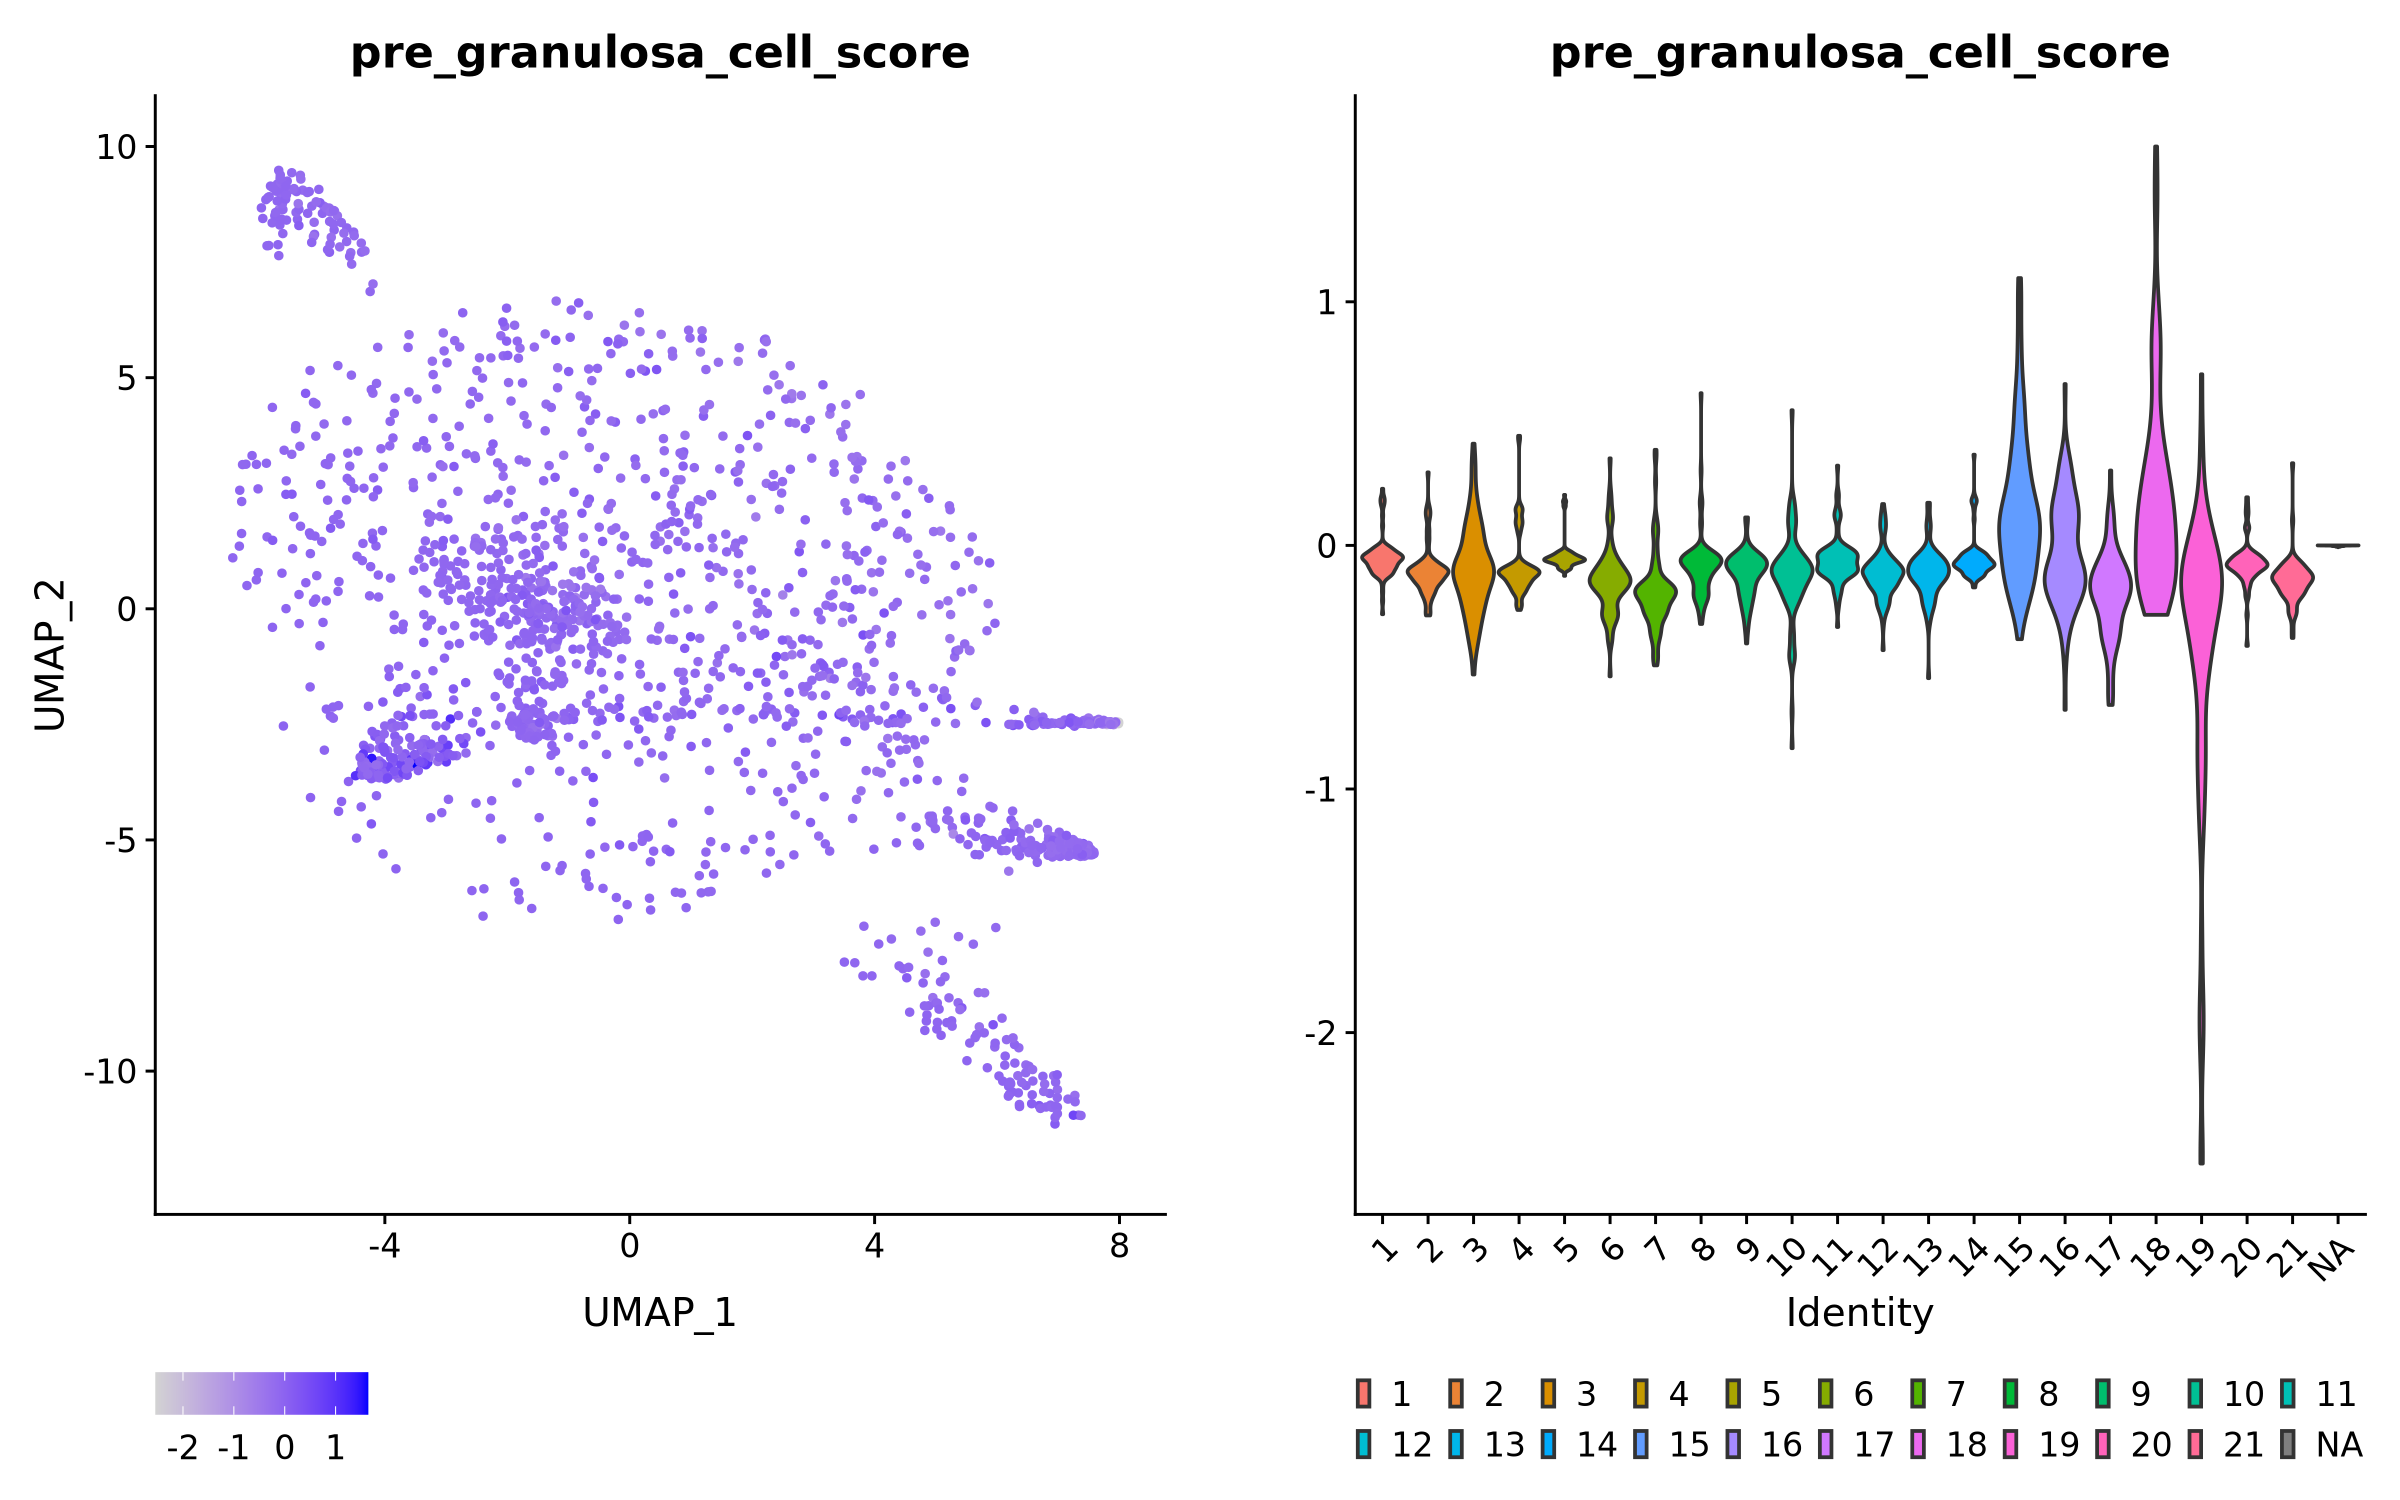

In [14]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "pre_granulosa_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "pre_granulosa_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

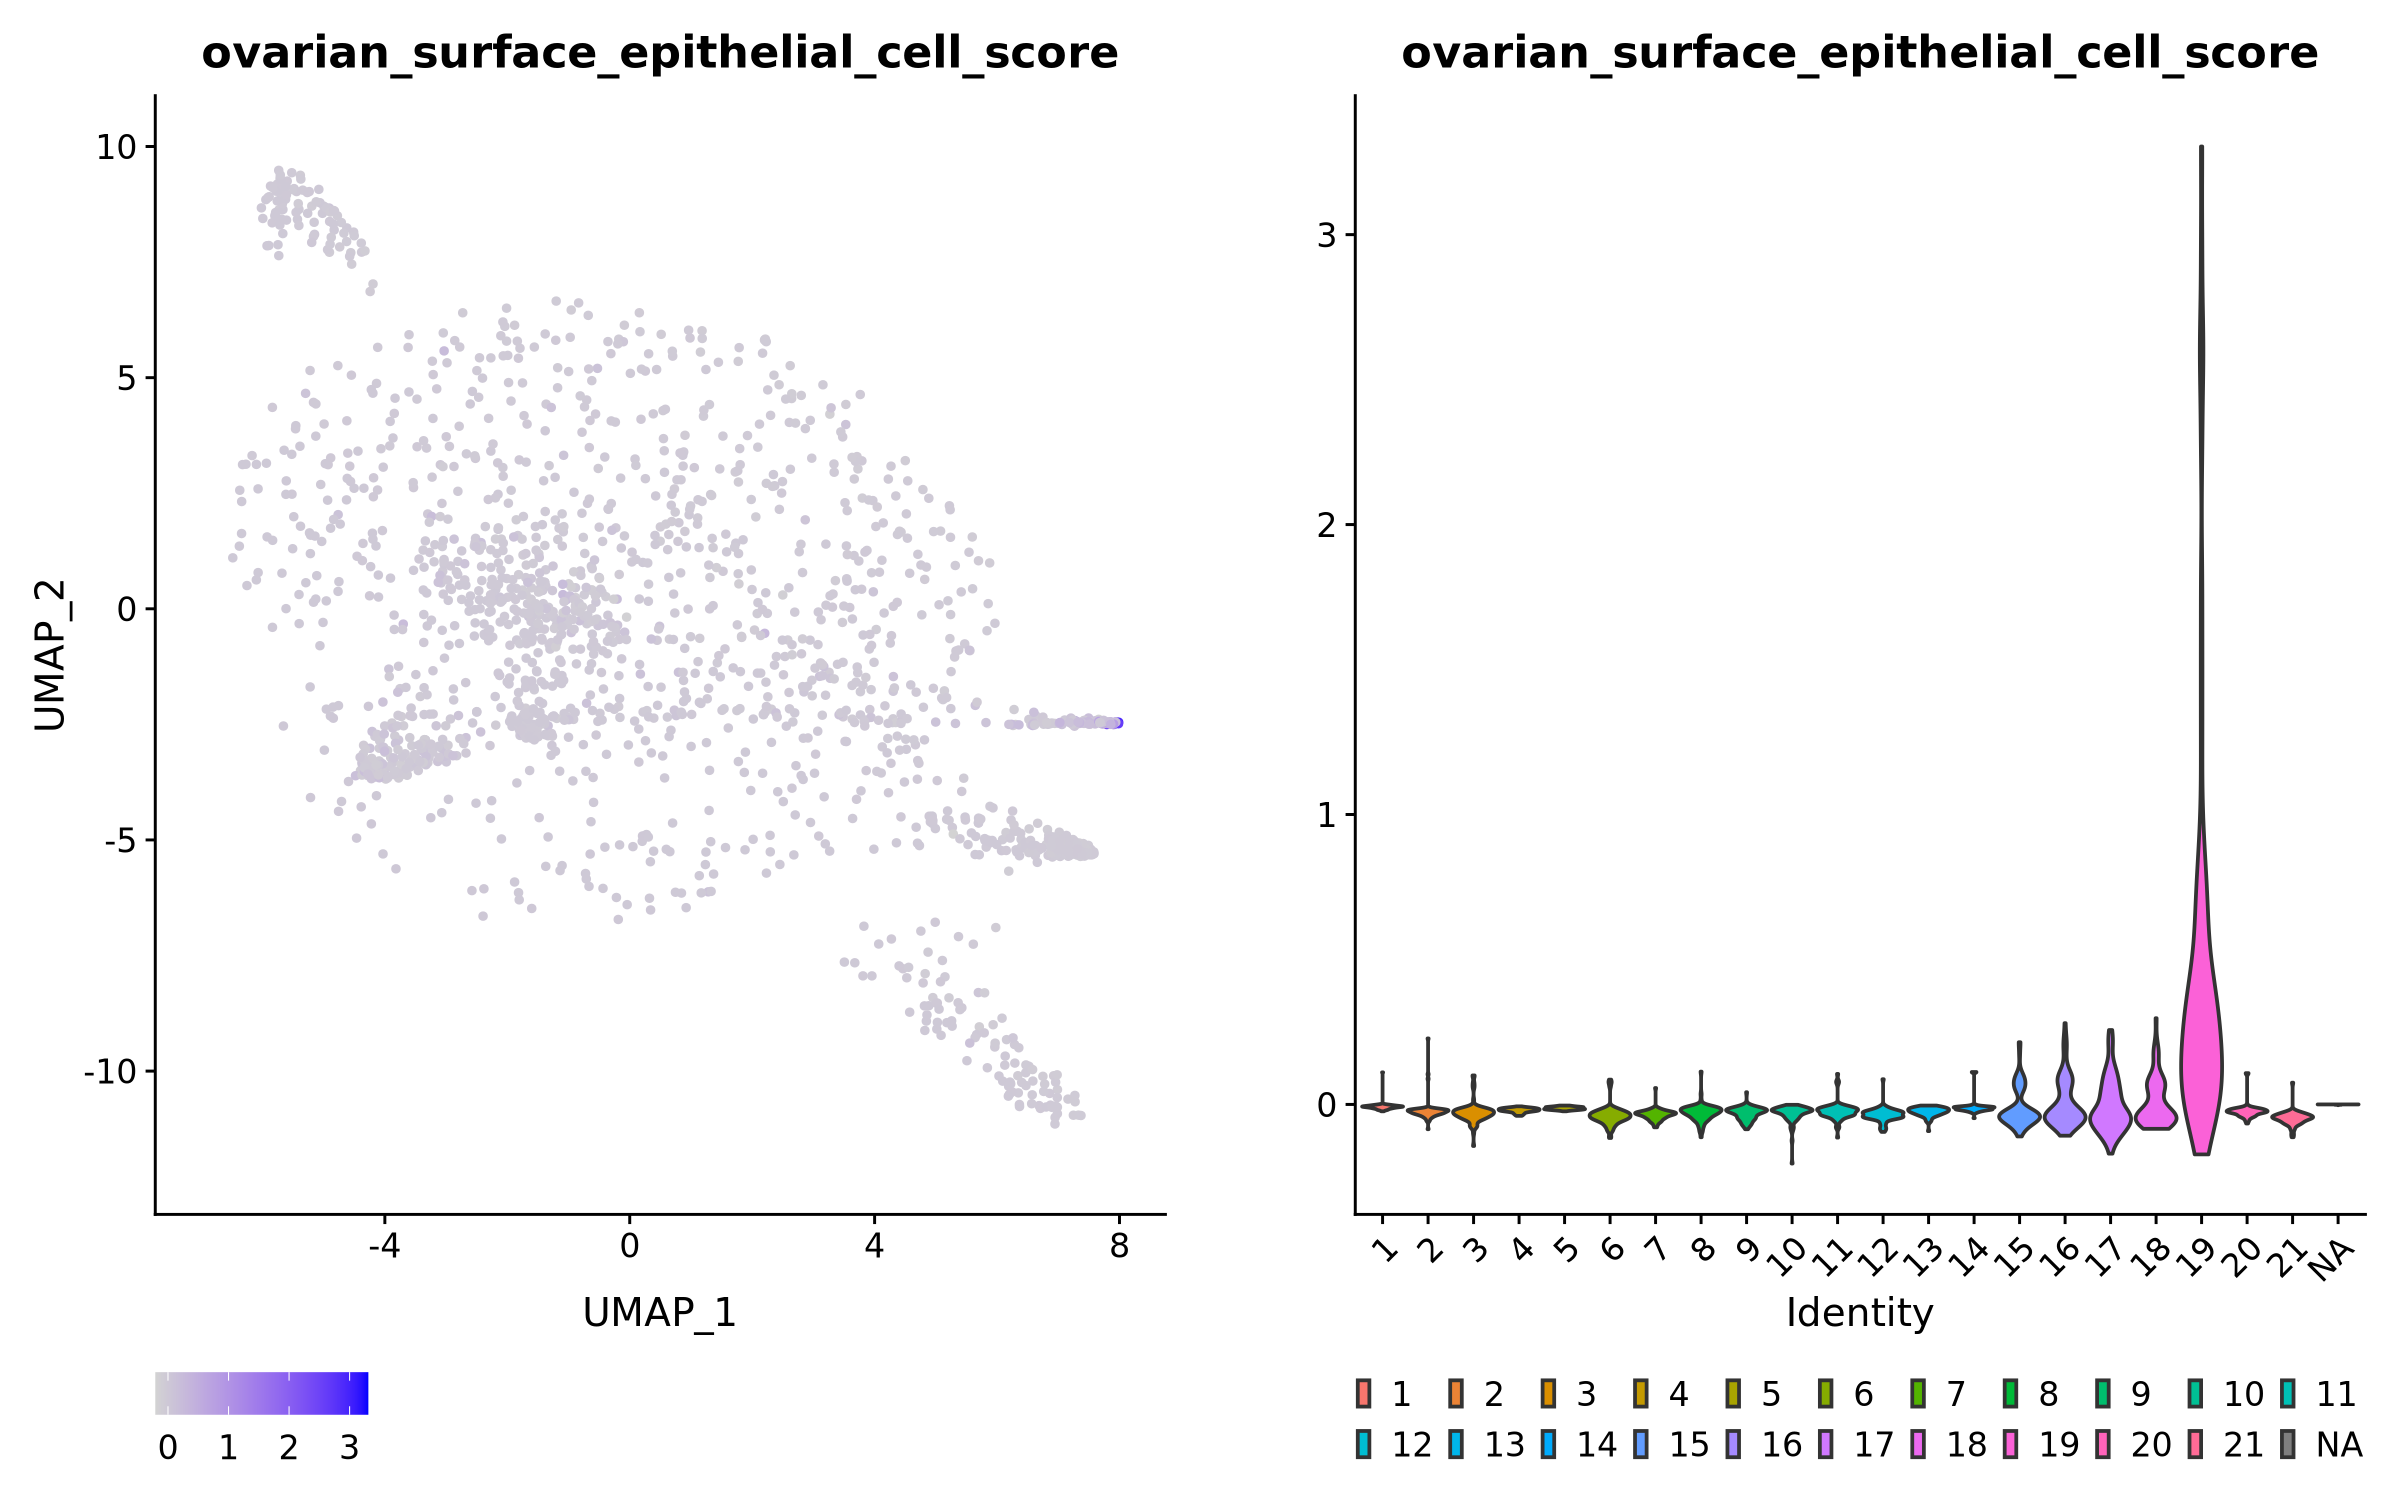

In [15]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "ovarian_surface_epithelial_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "ovarian_surface_epithelial_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

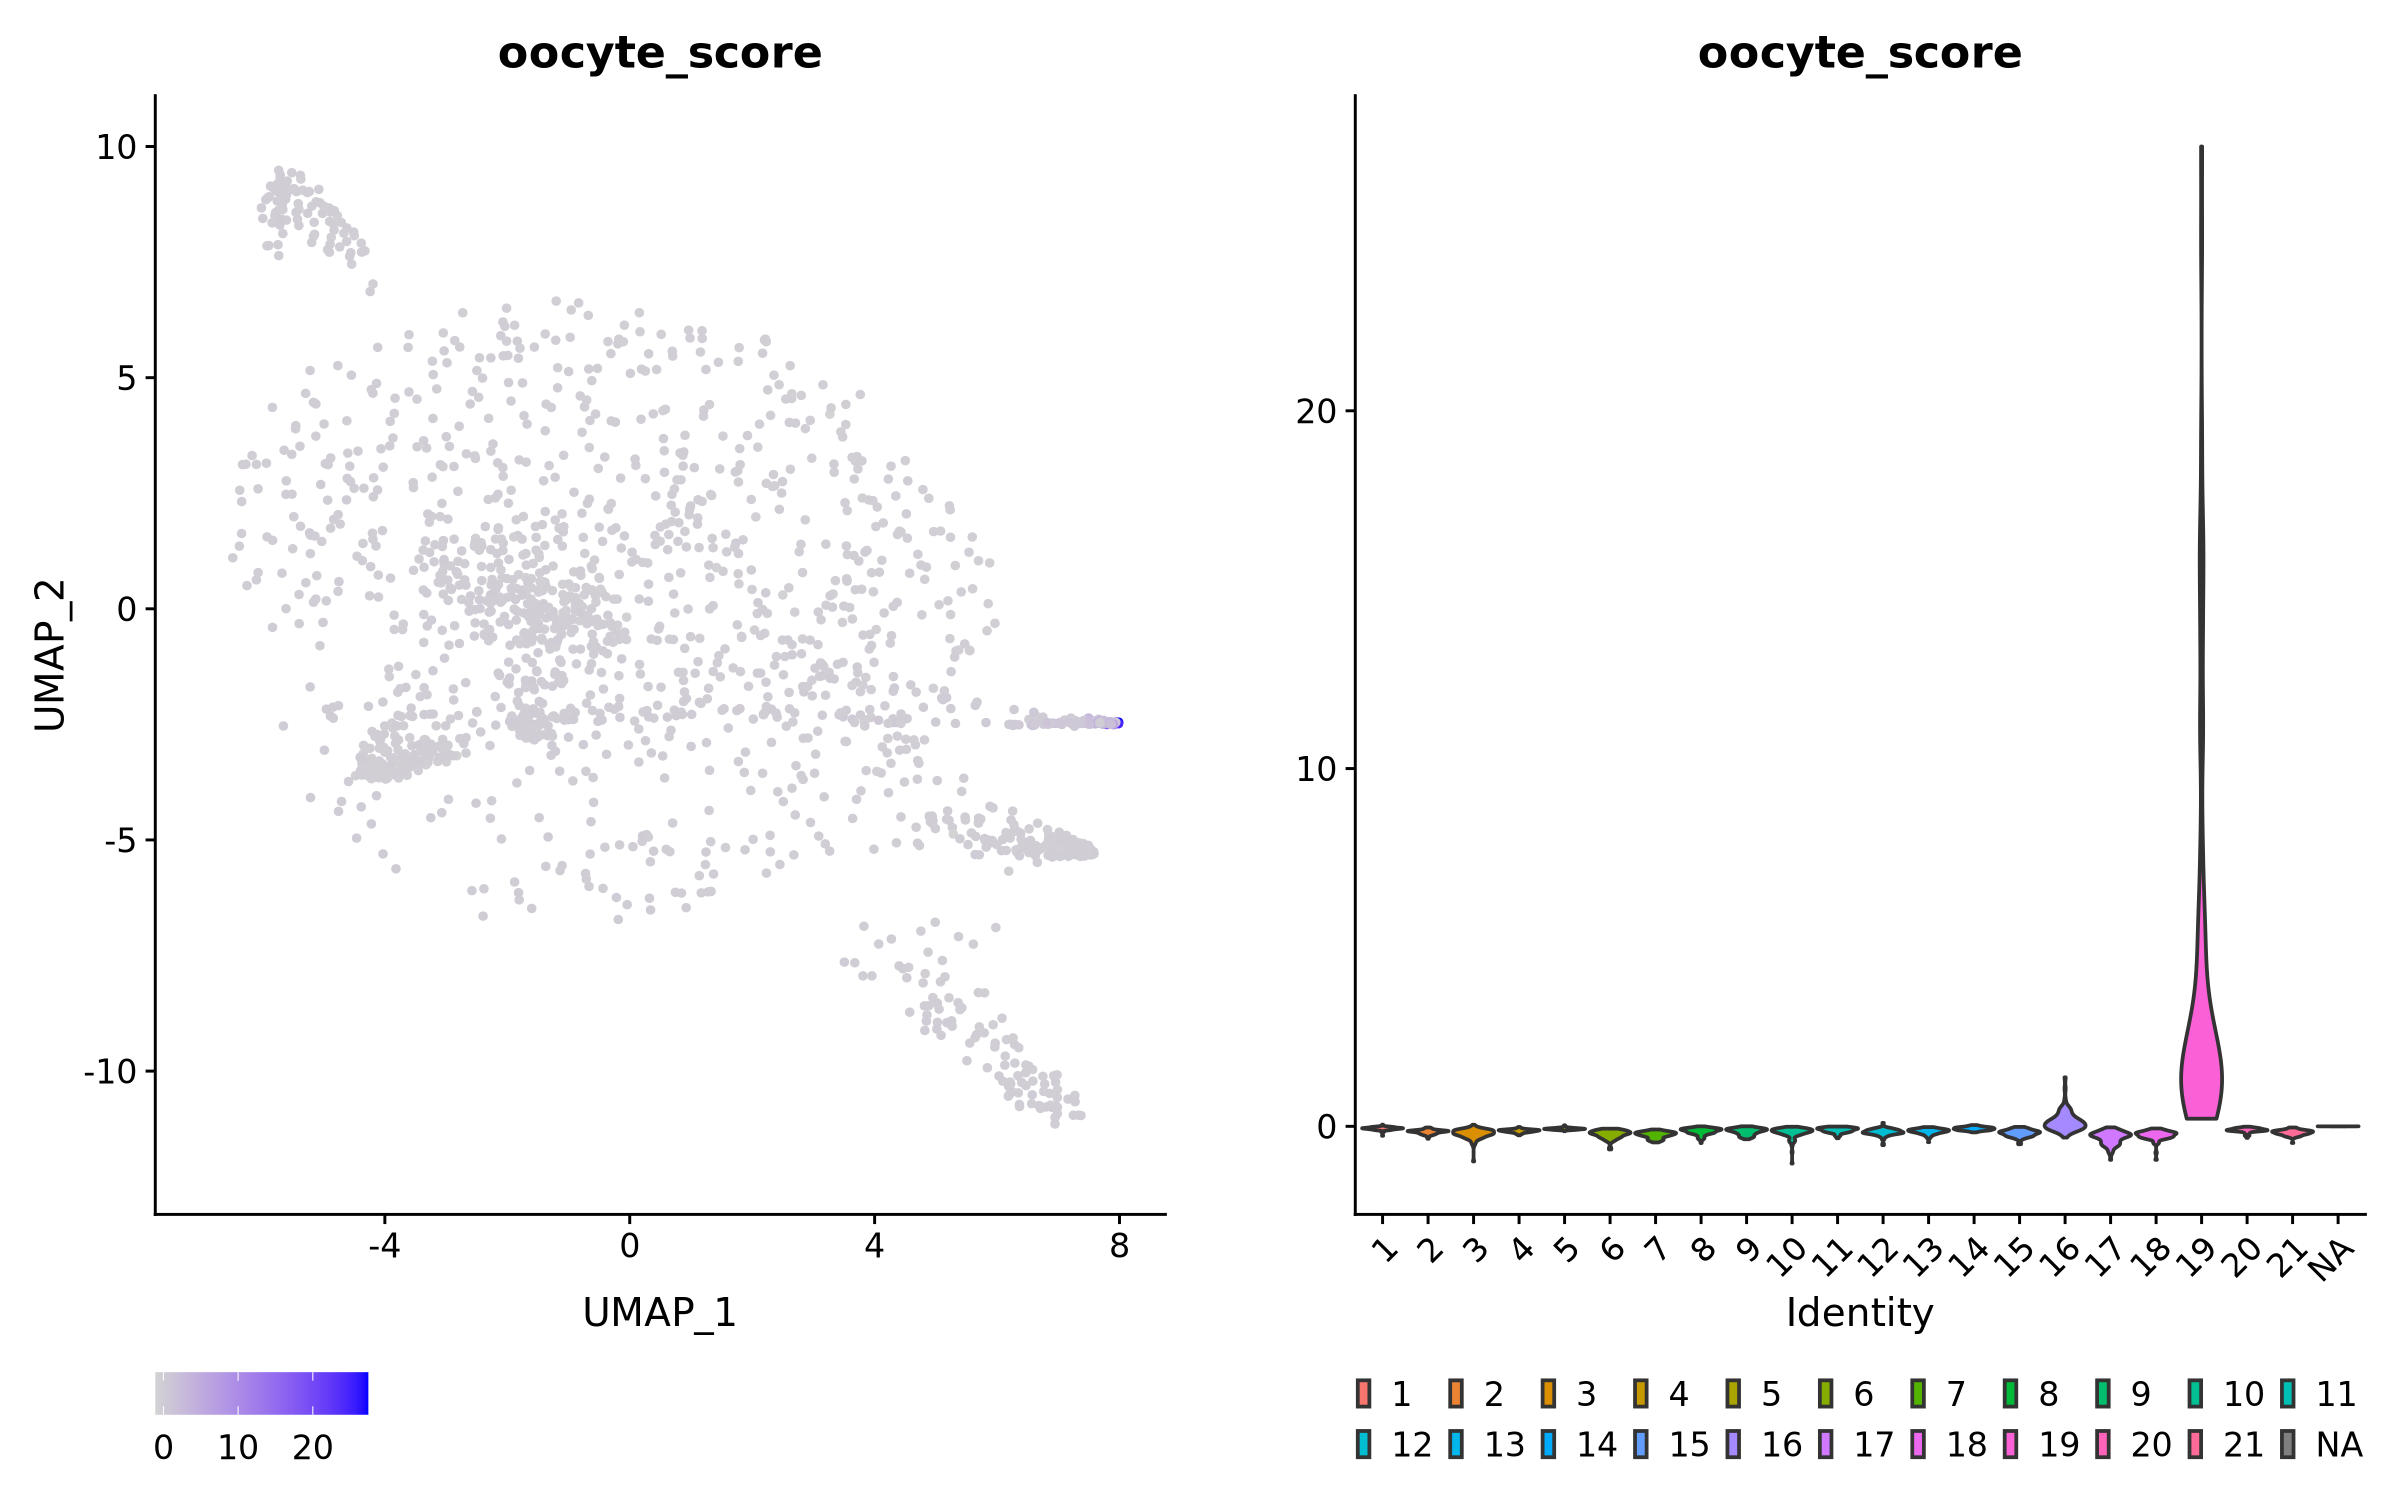

In [16]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "oocyte_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "oocyte_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

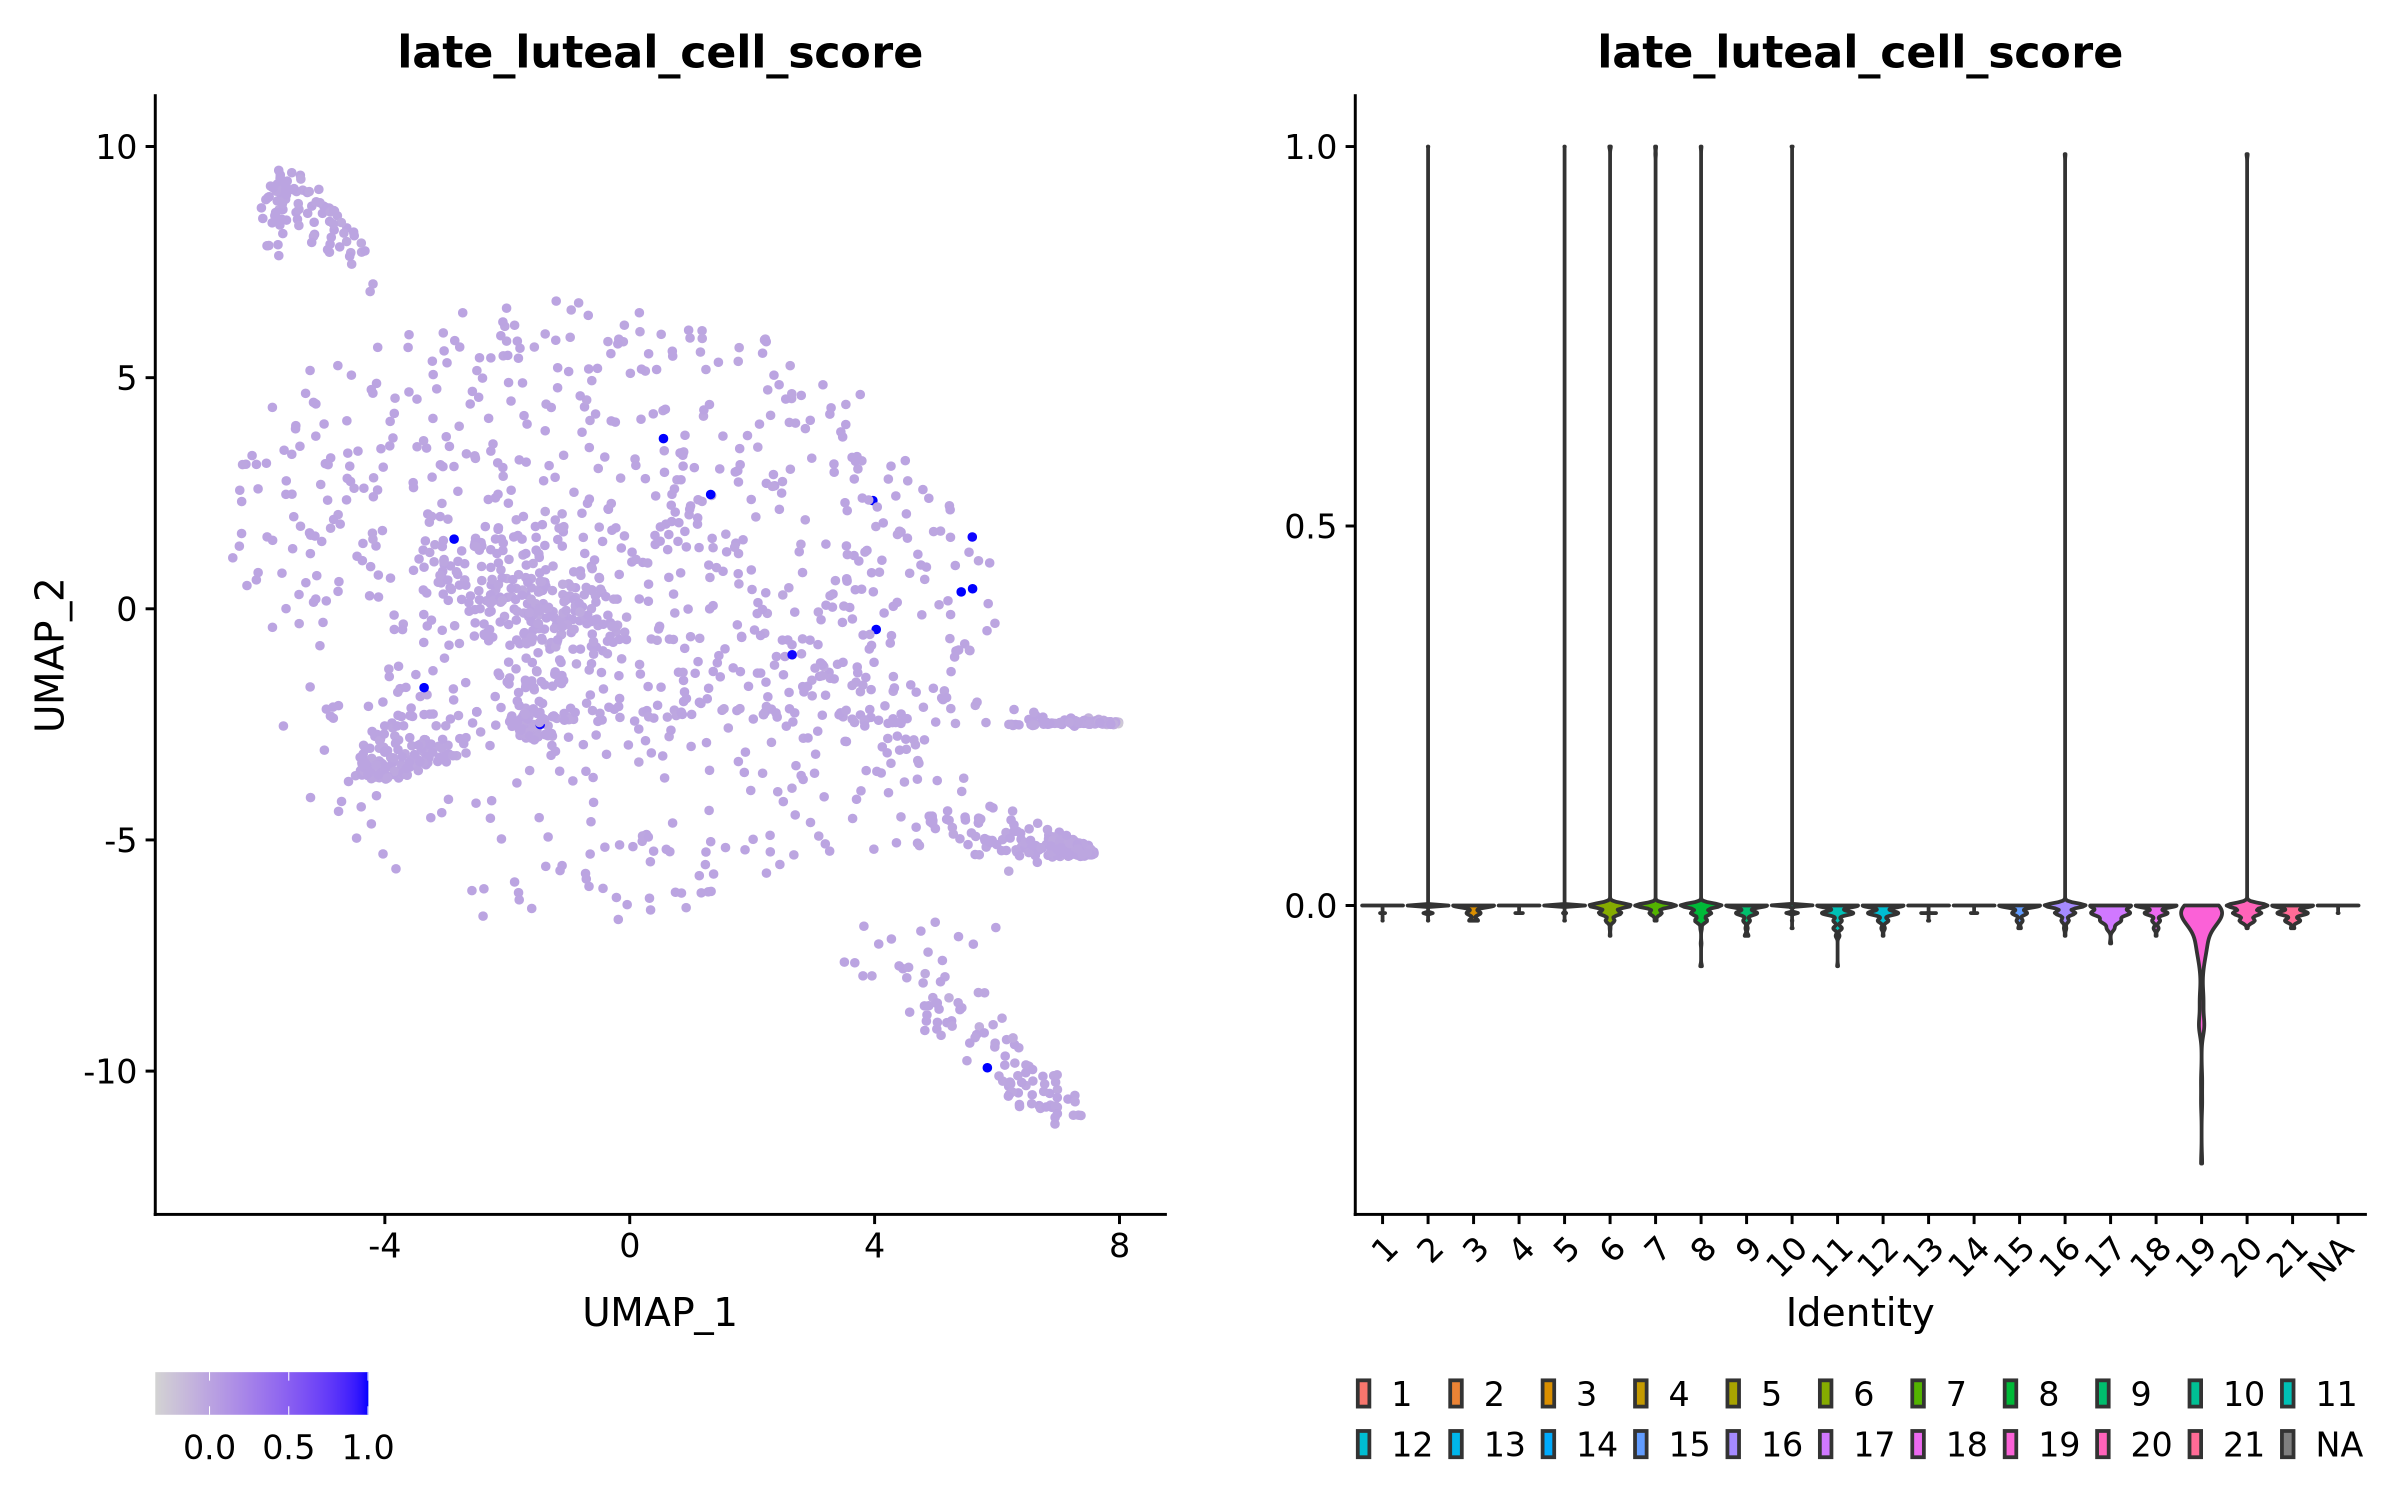

In [17]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "late_luteal_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "late_luteal_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

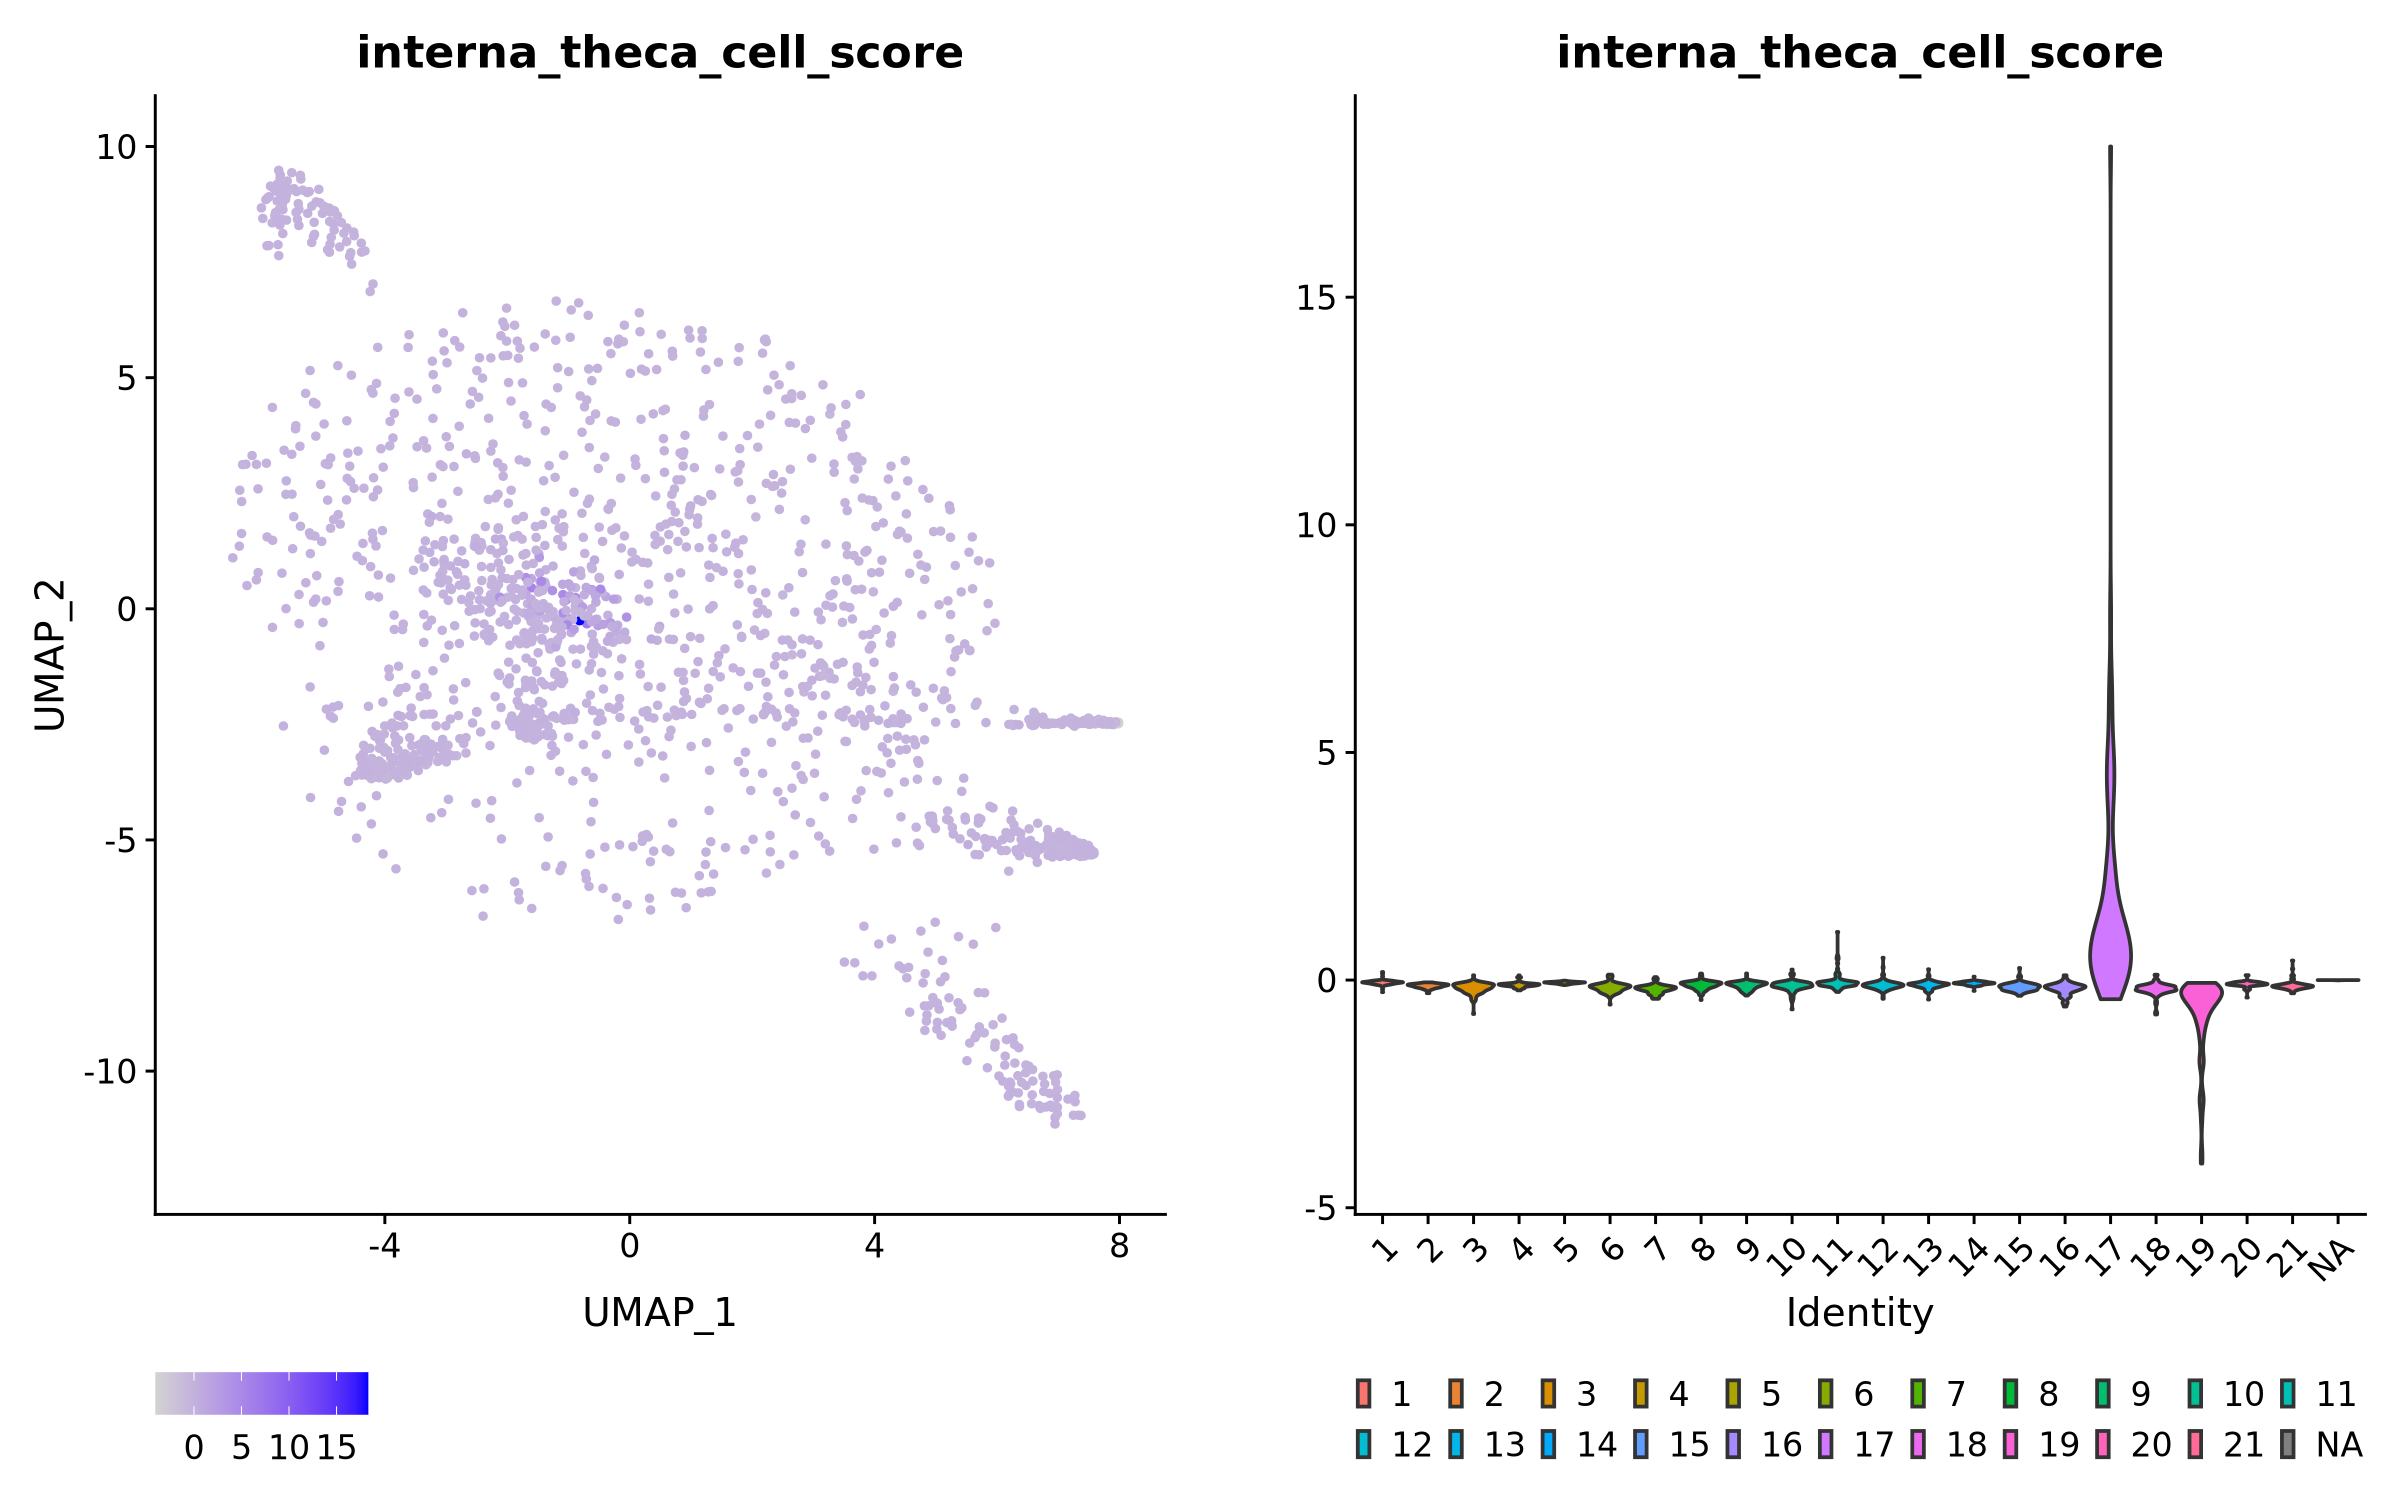

In [18]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "interna_theca_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "interna_theca_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

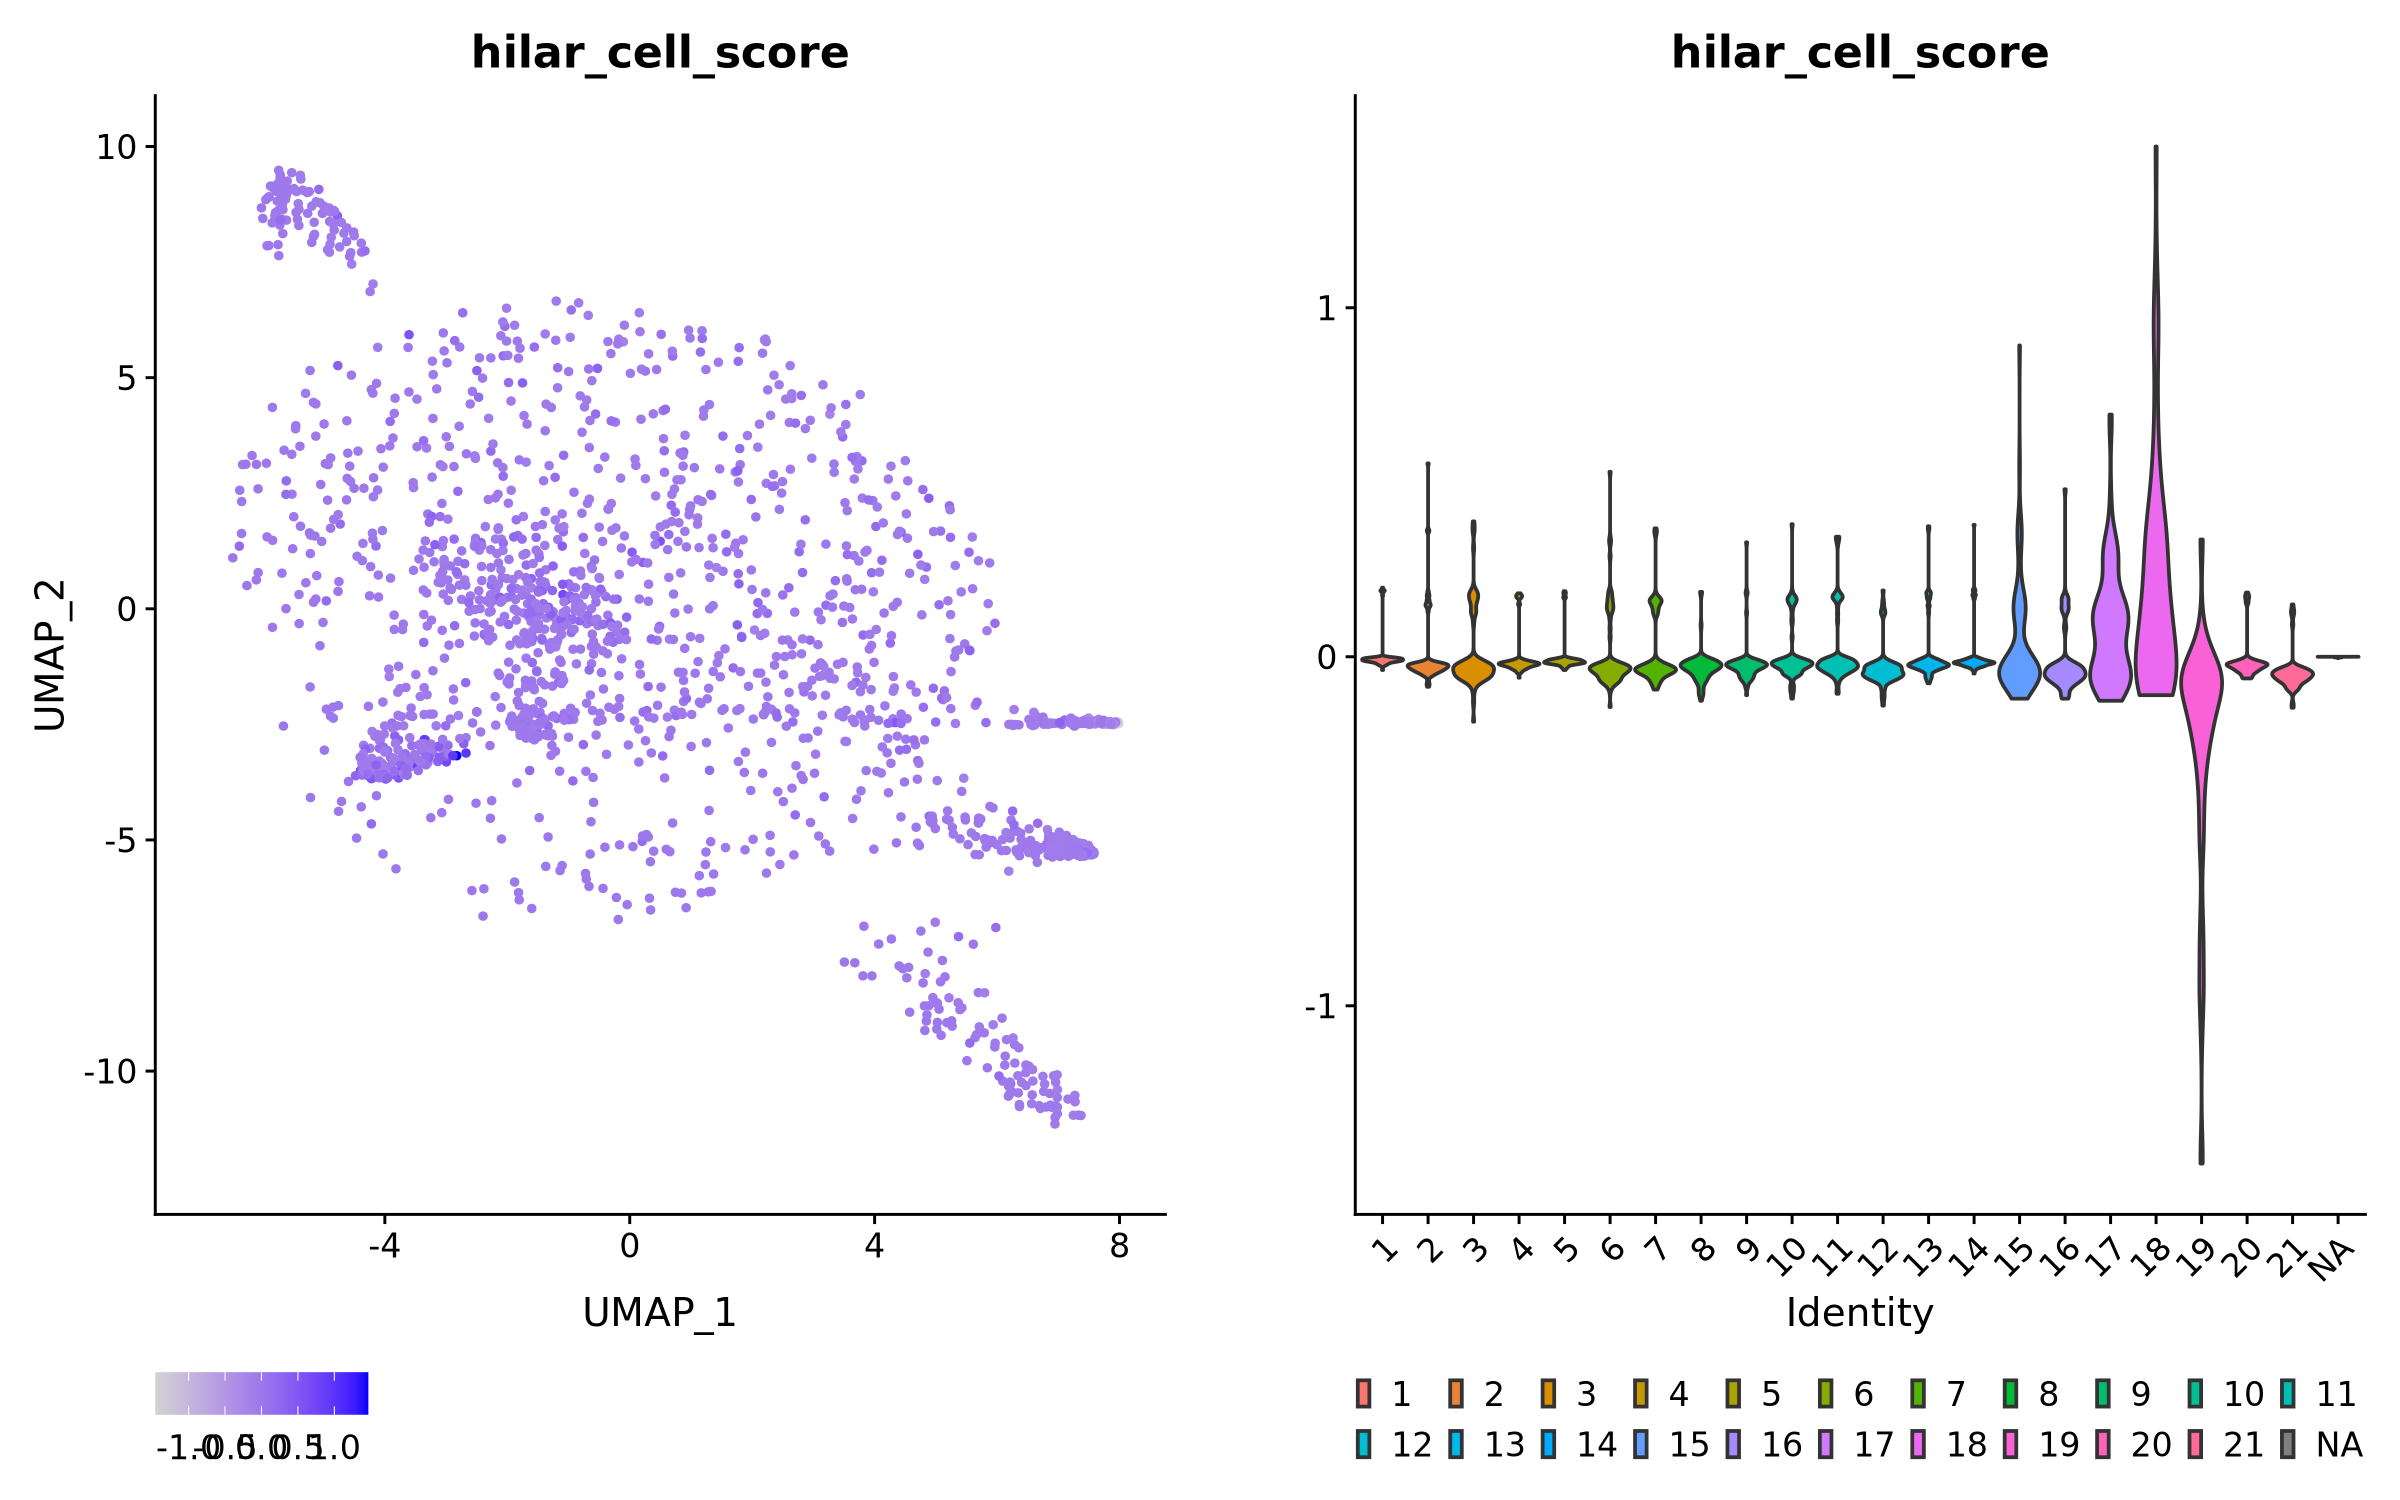

In [19]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "hilar_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "hilar_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

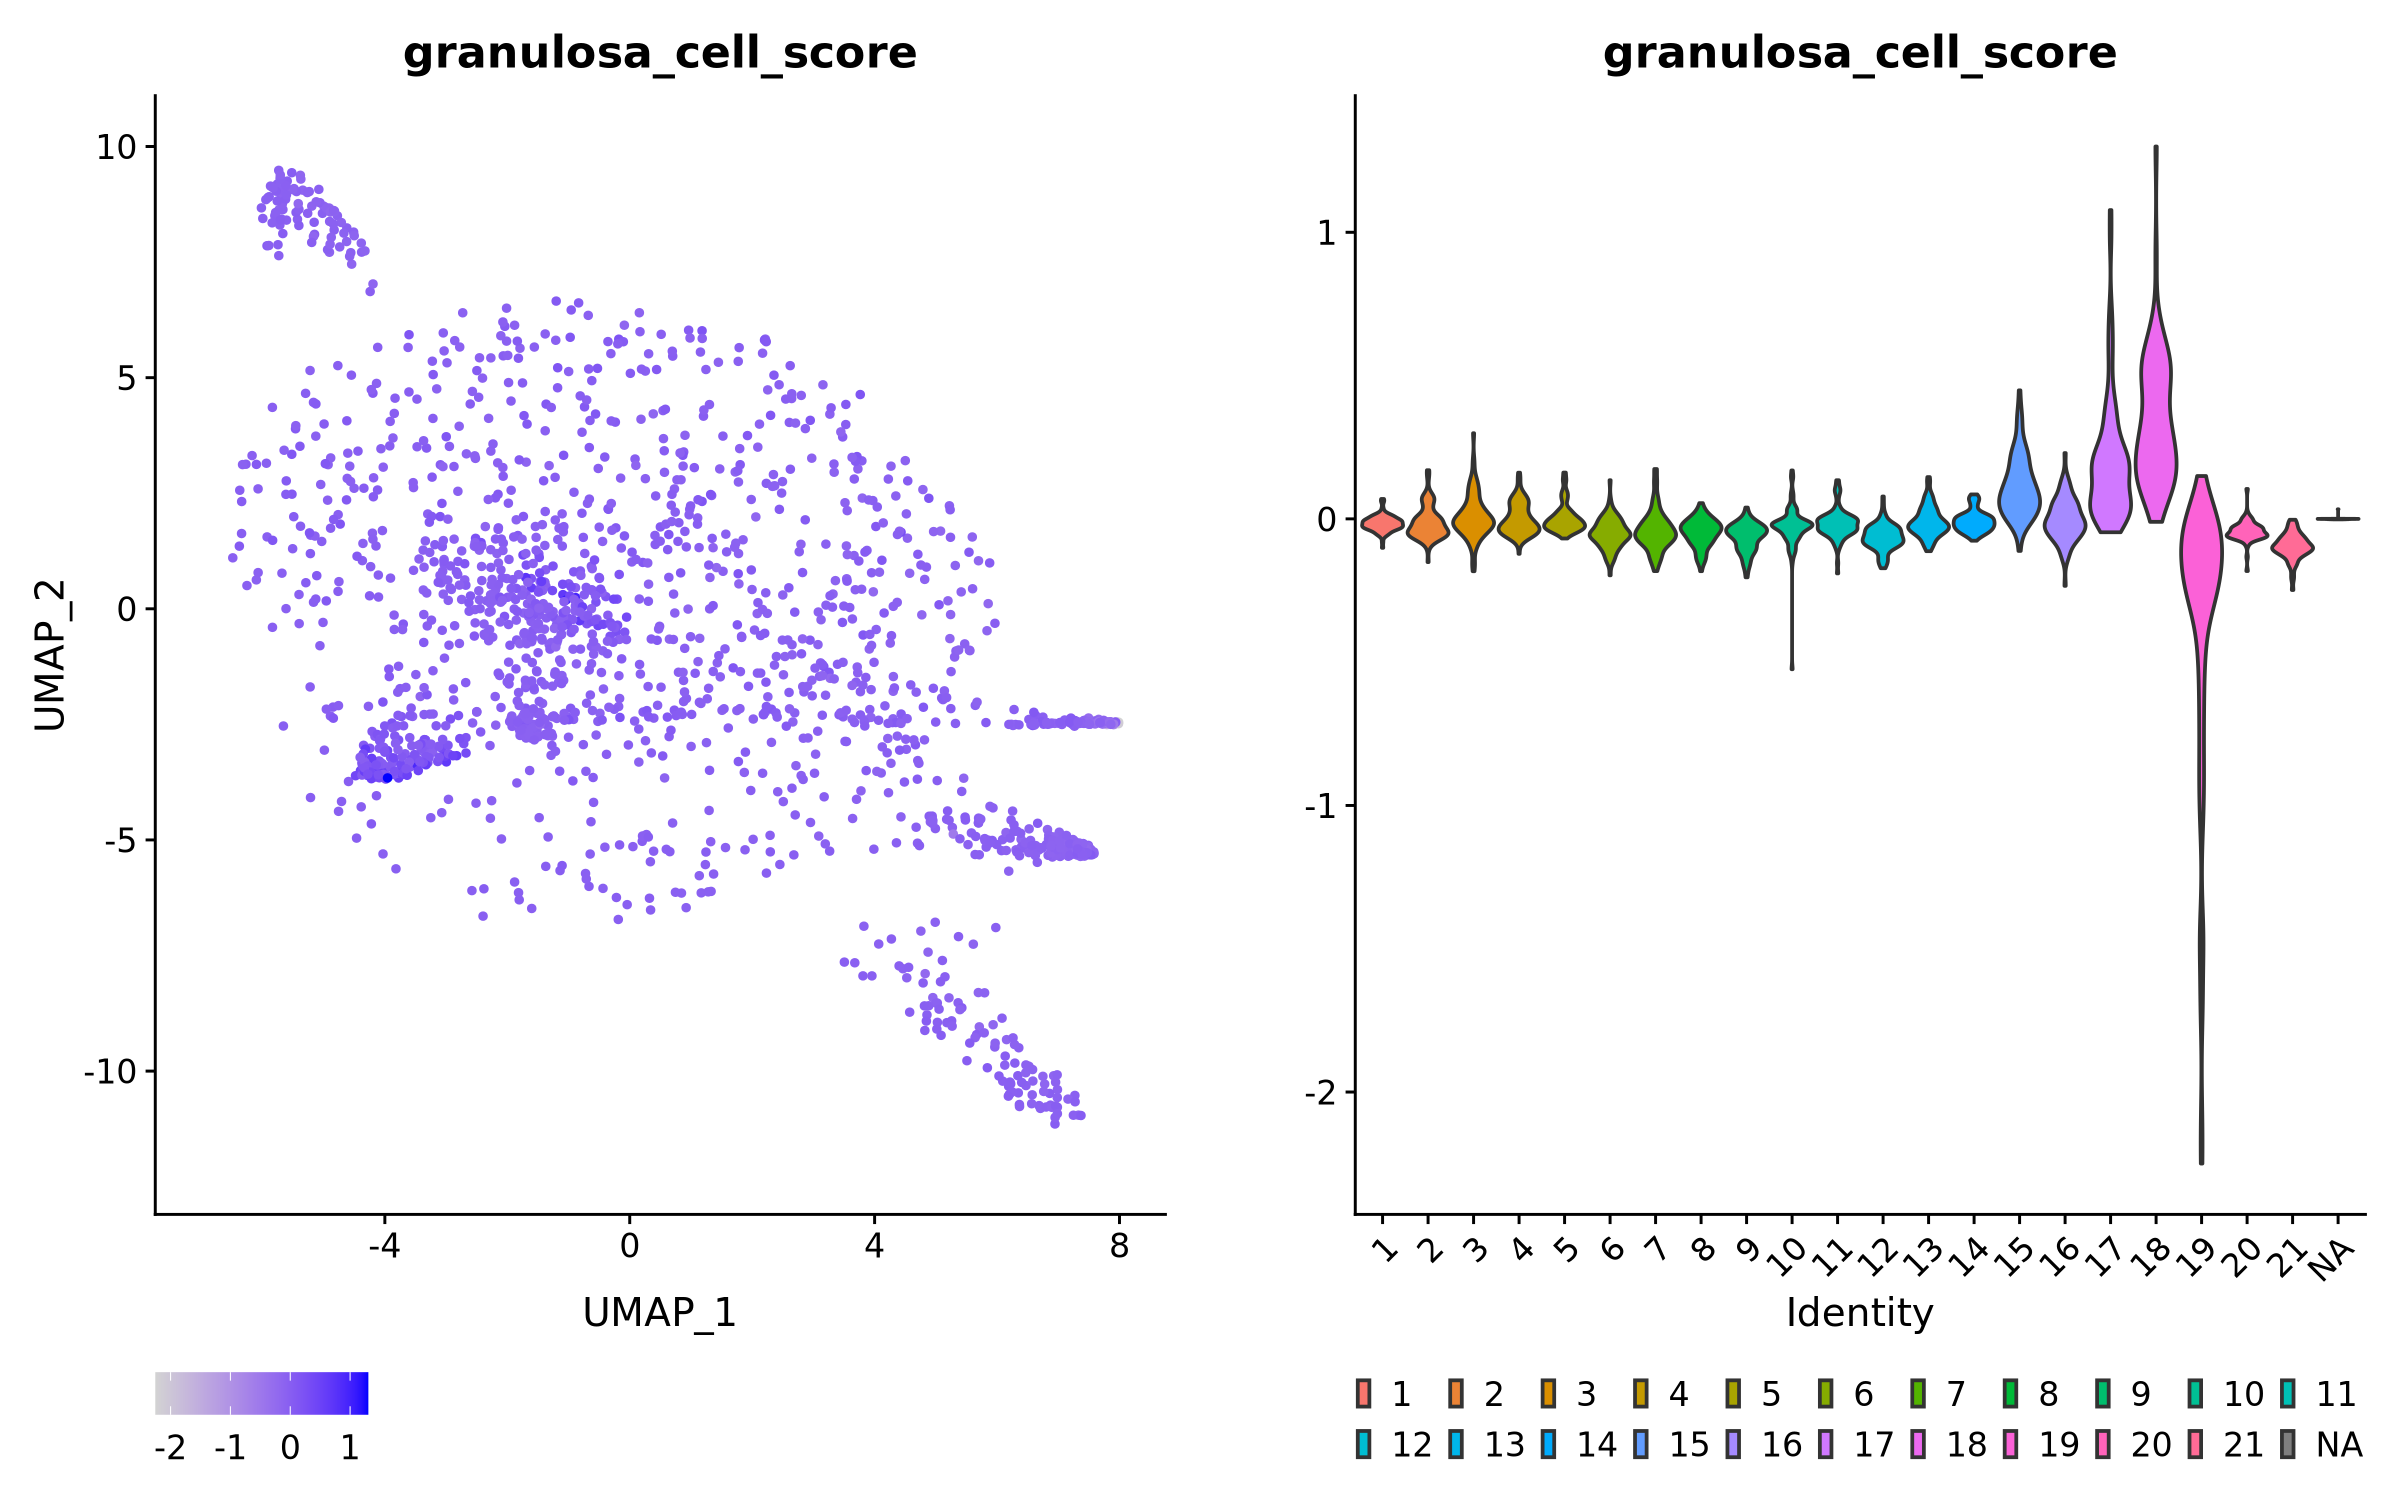

In [20]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "granulosa_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "granulosa_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

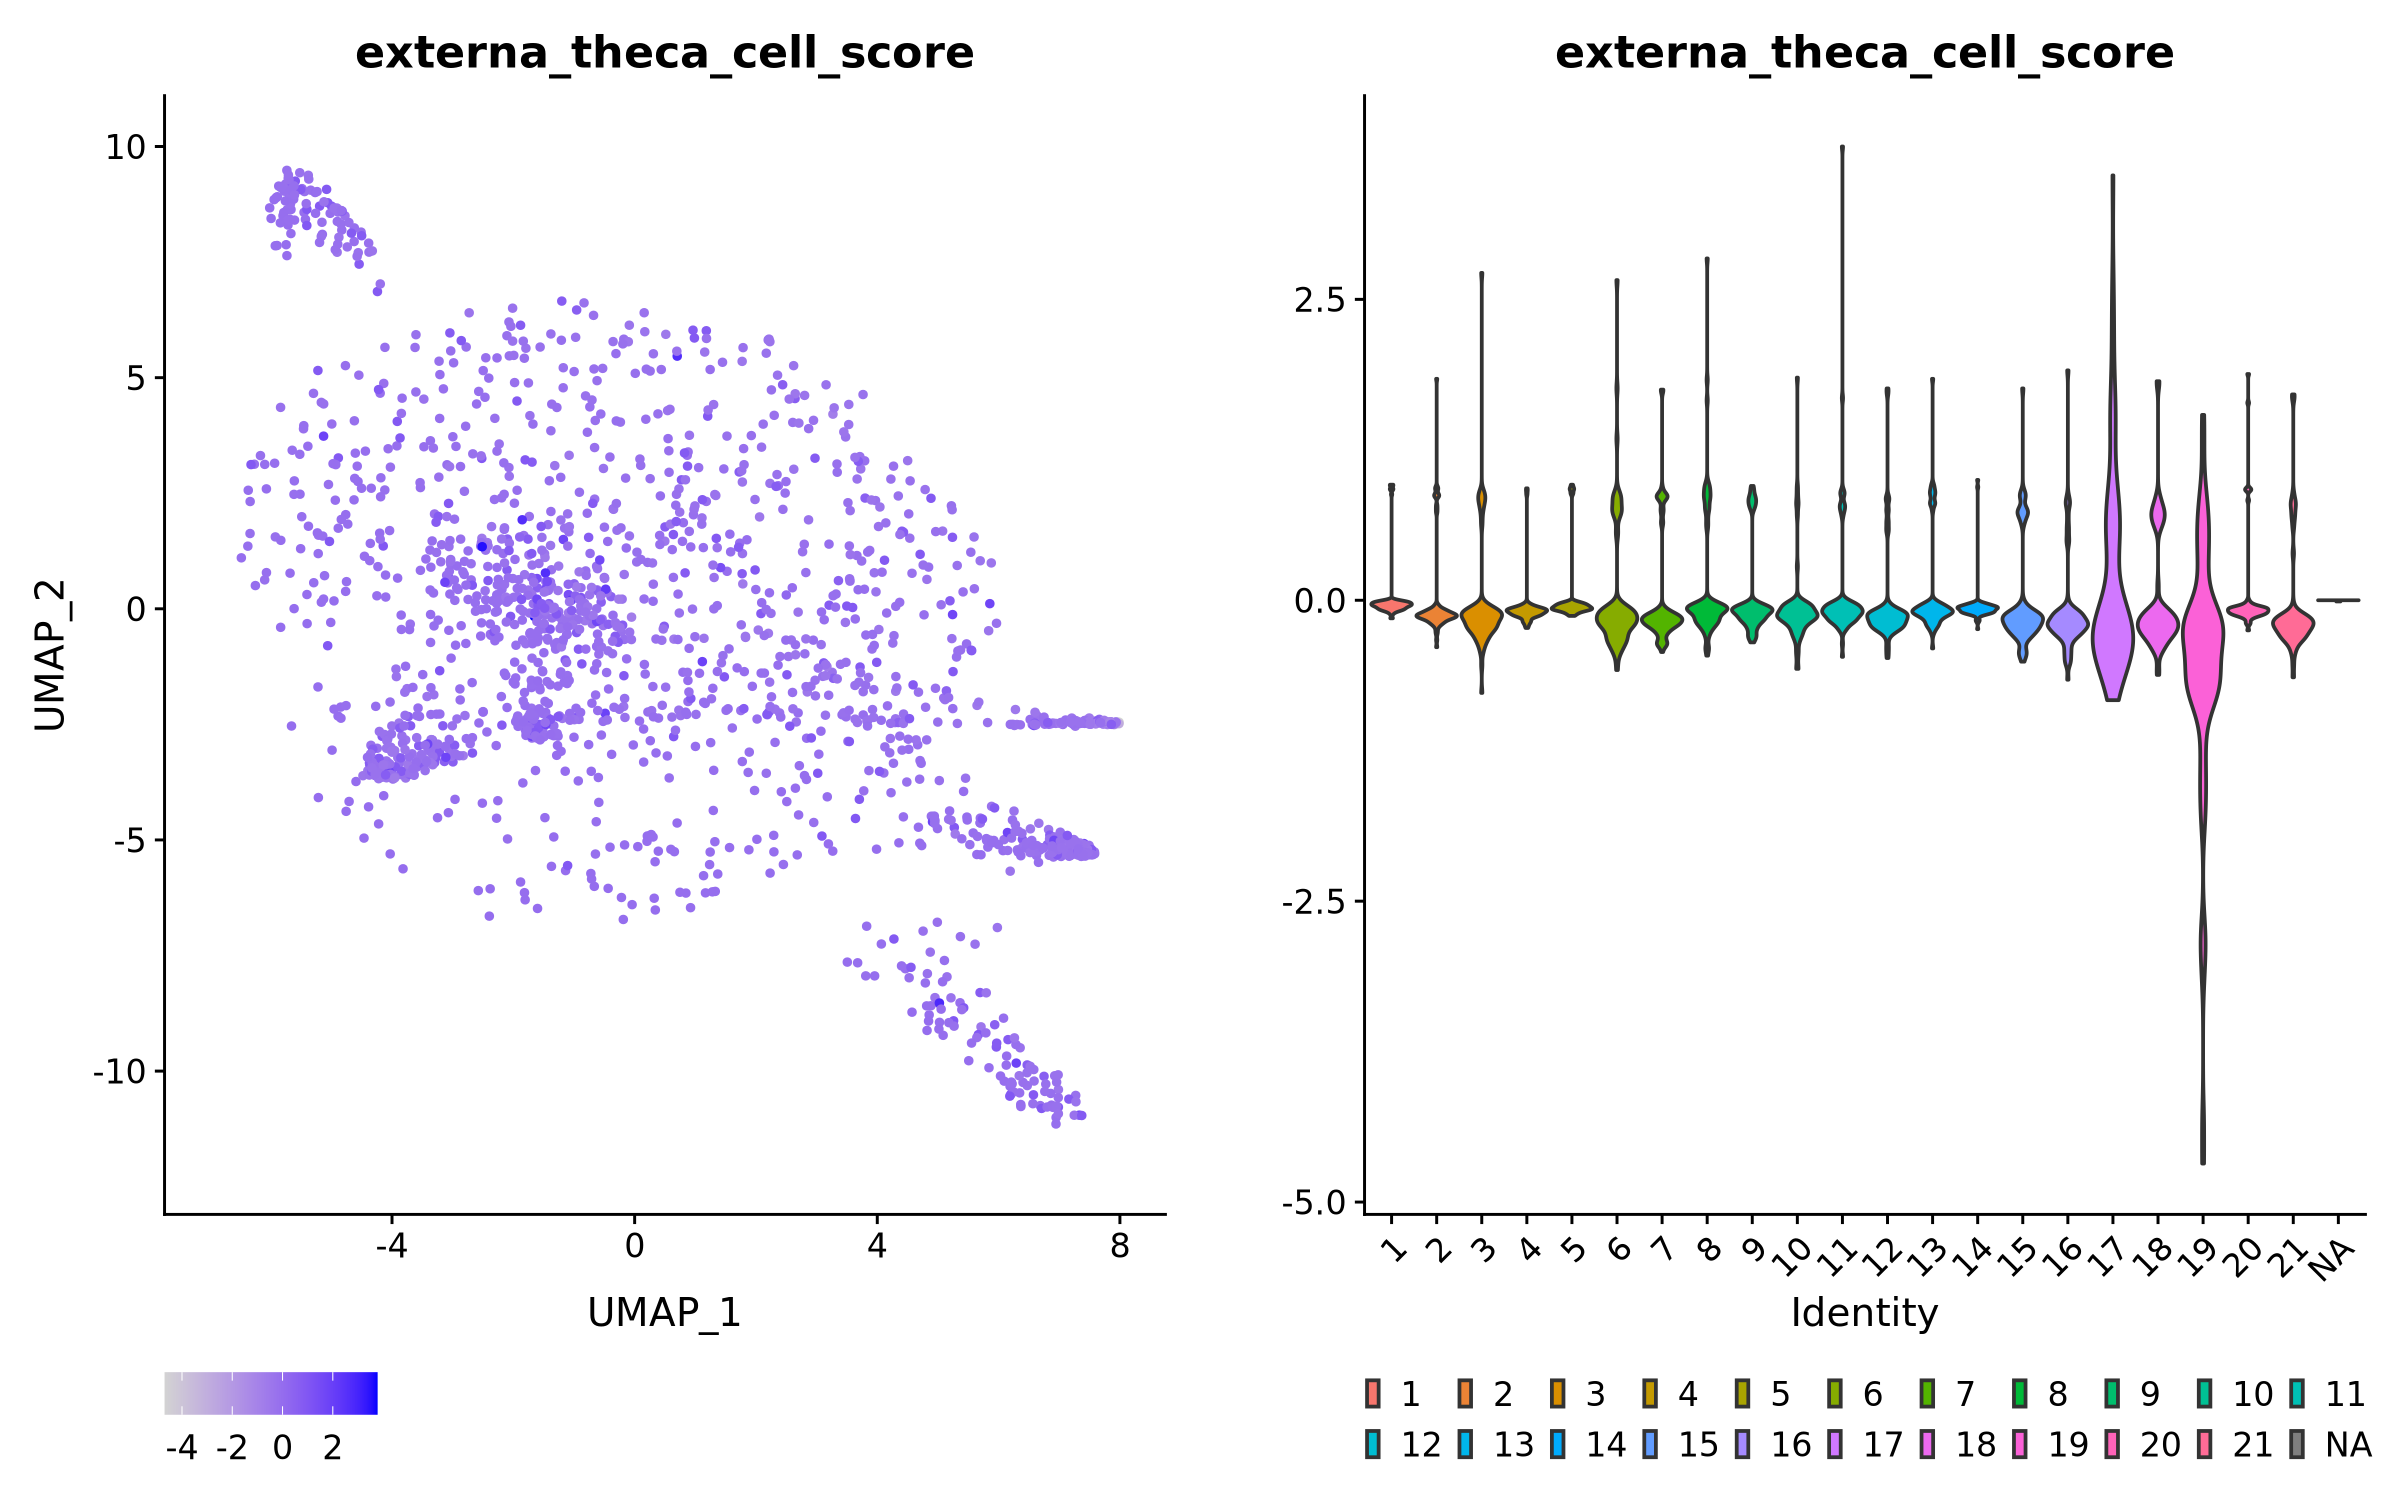

In [21]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "externa_theca_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "externa_theca_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

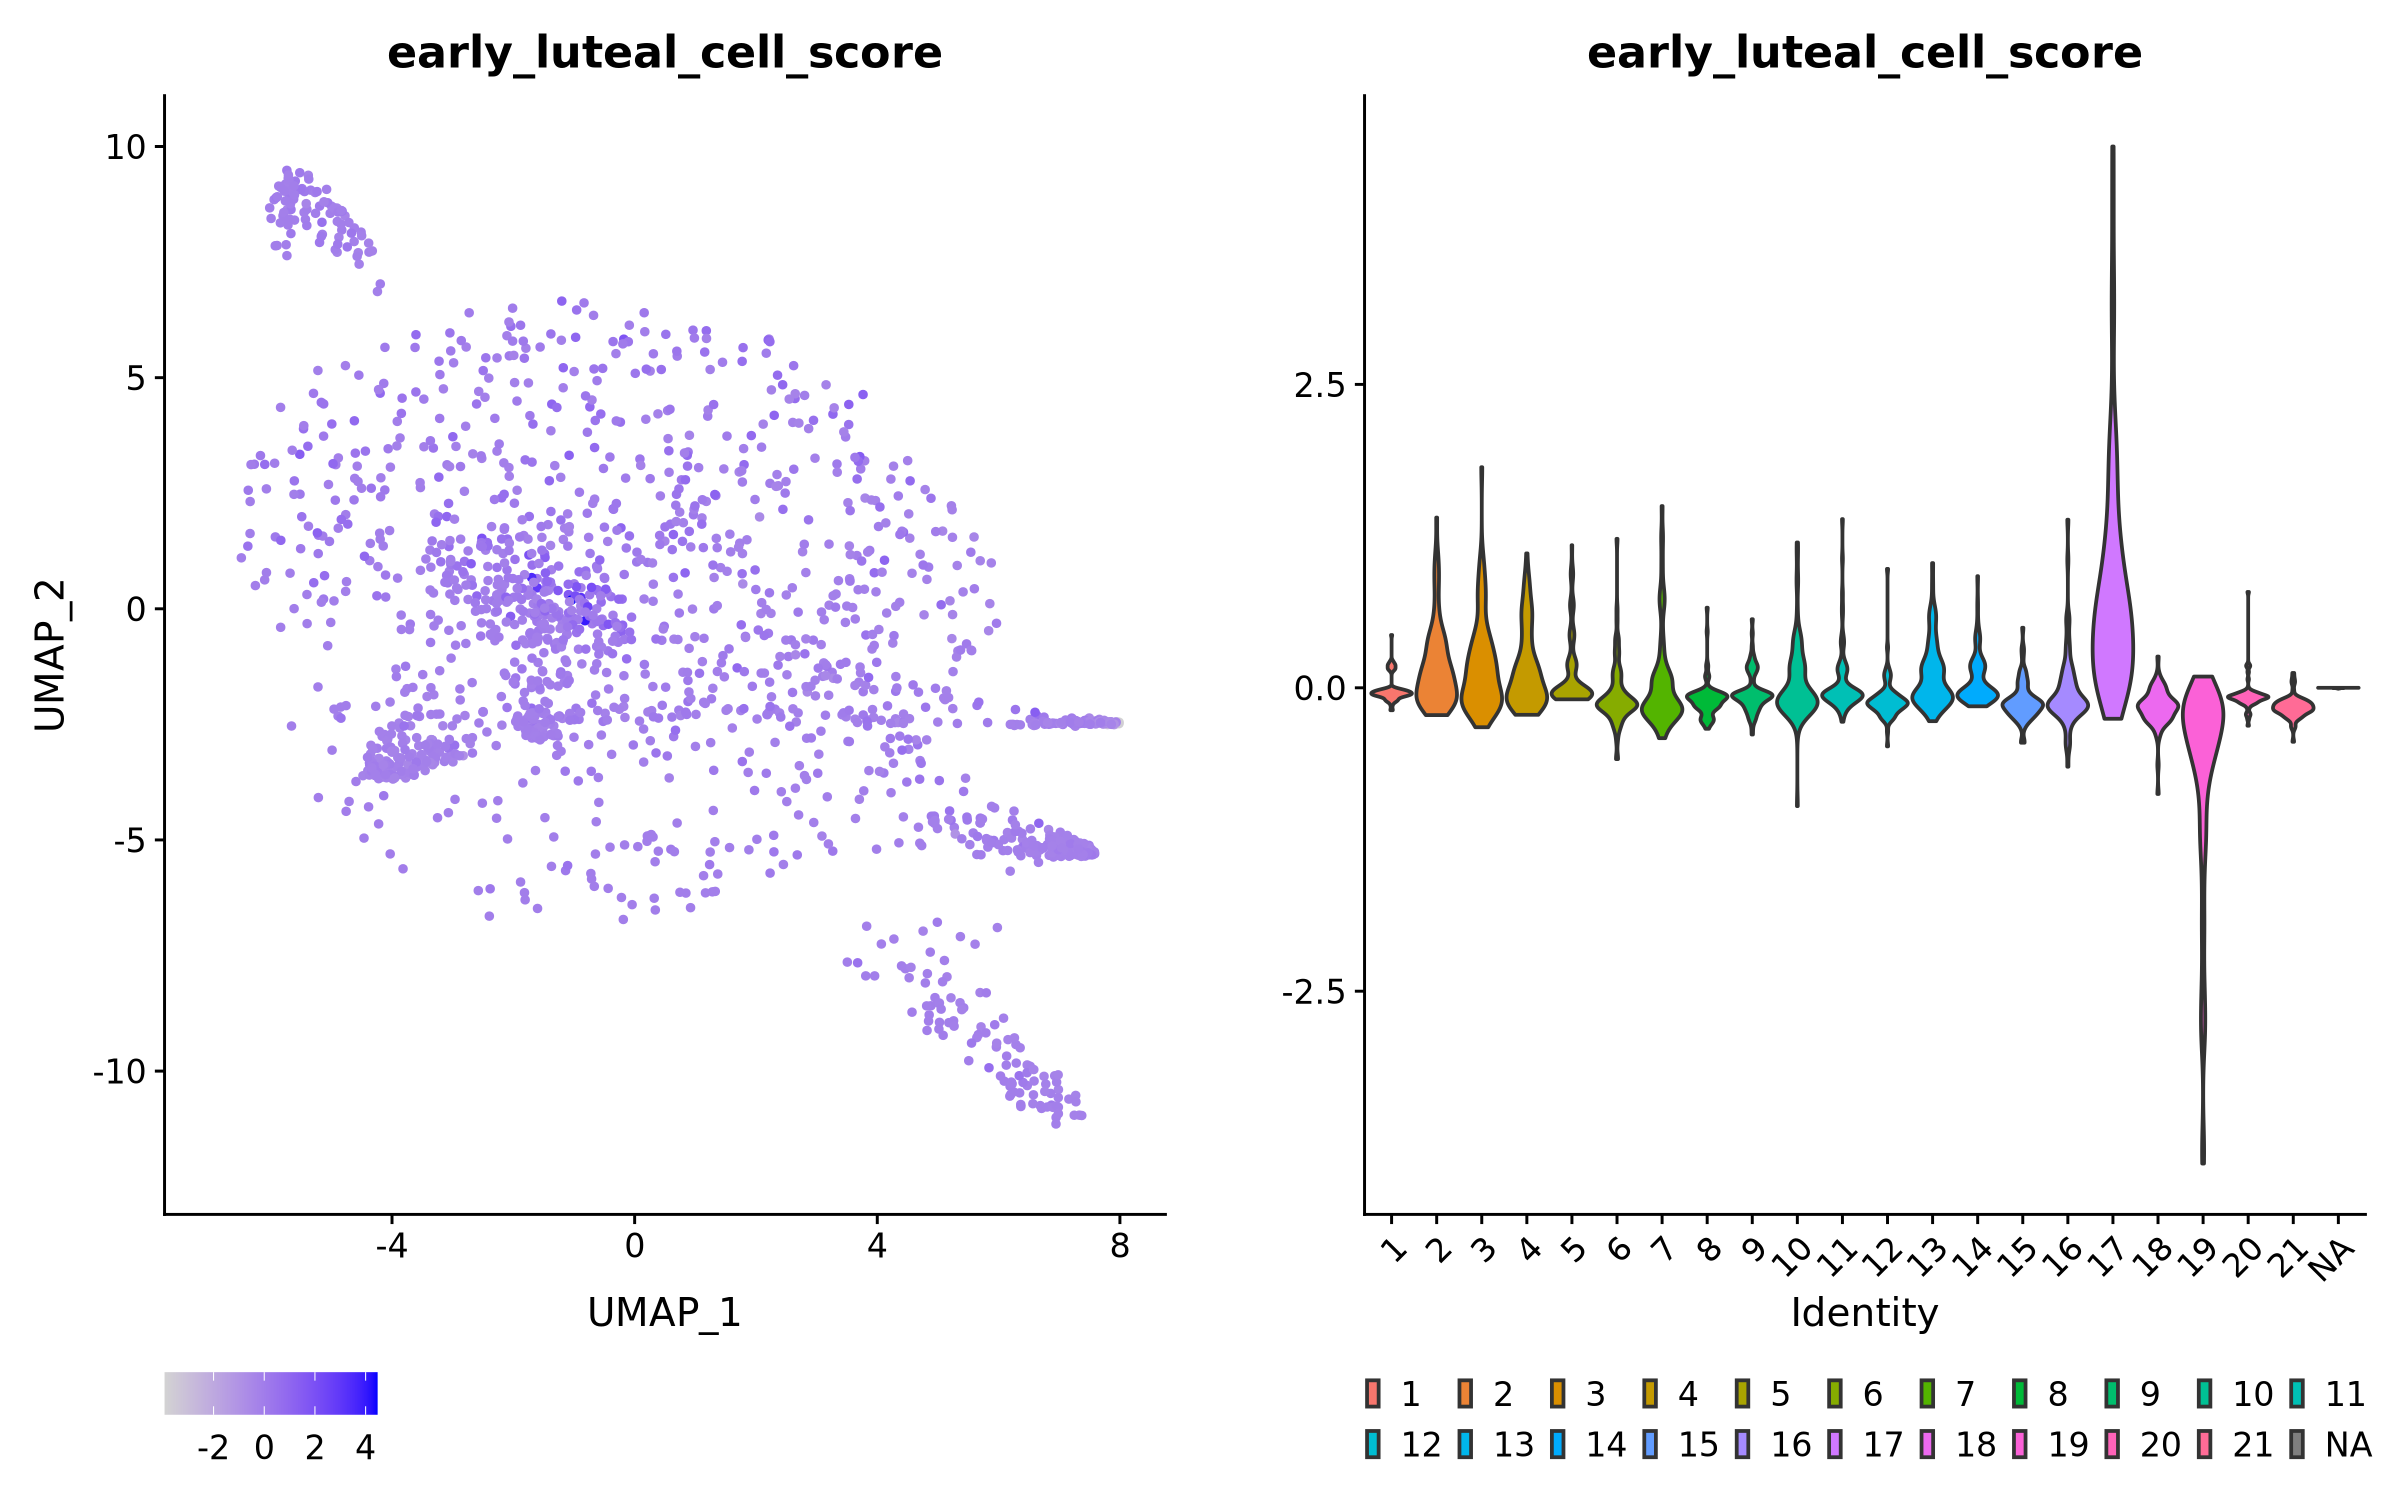

In [22]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "early_luteal_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "early_luteal_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

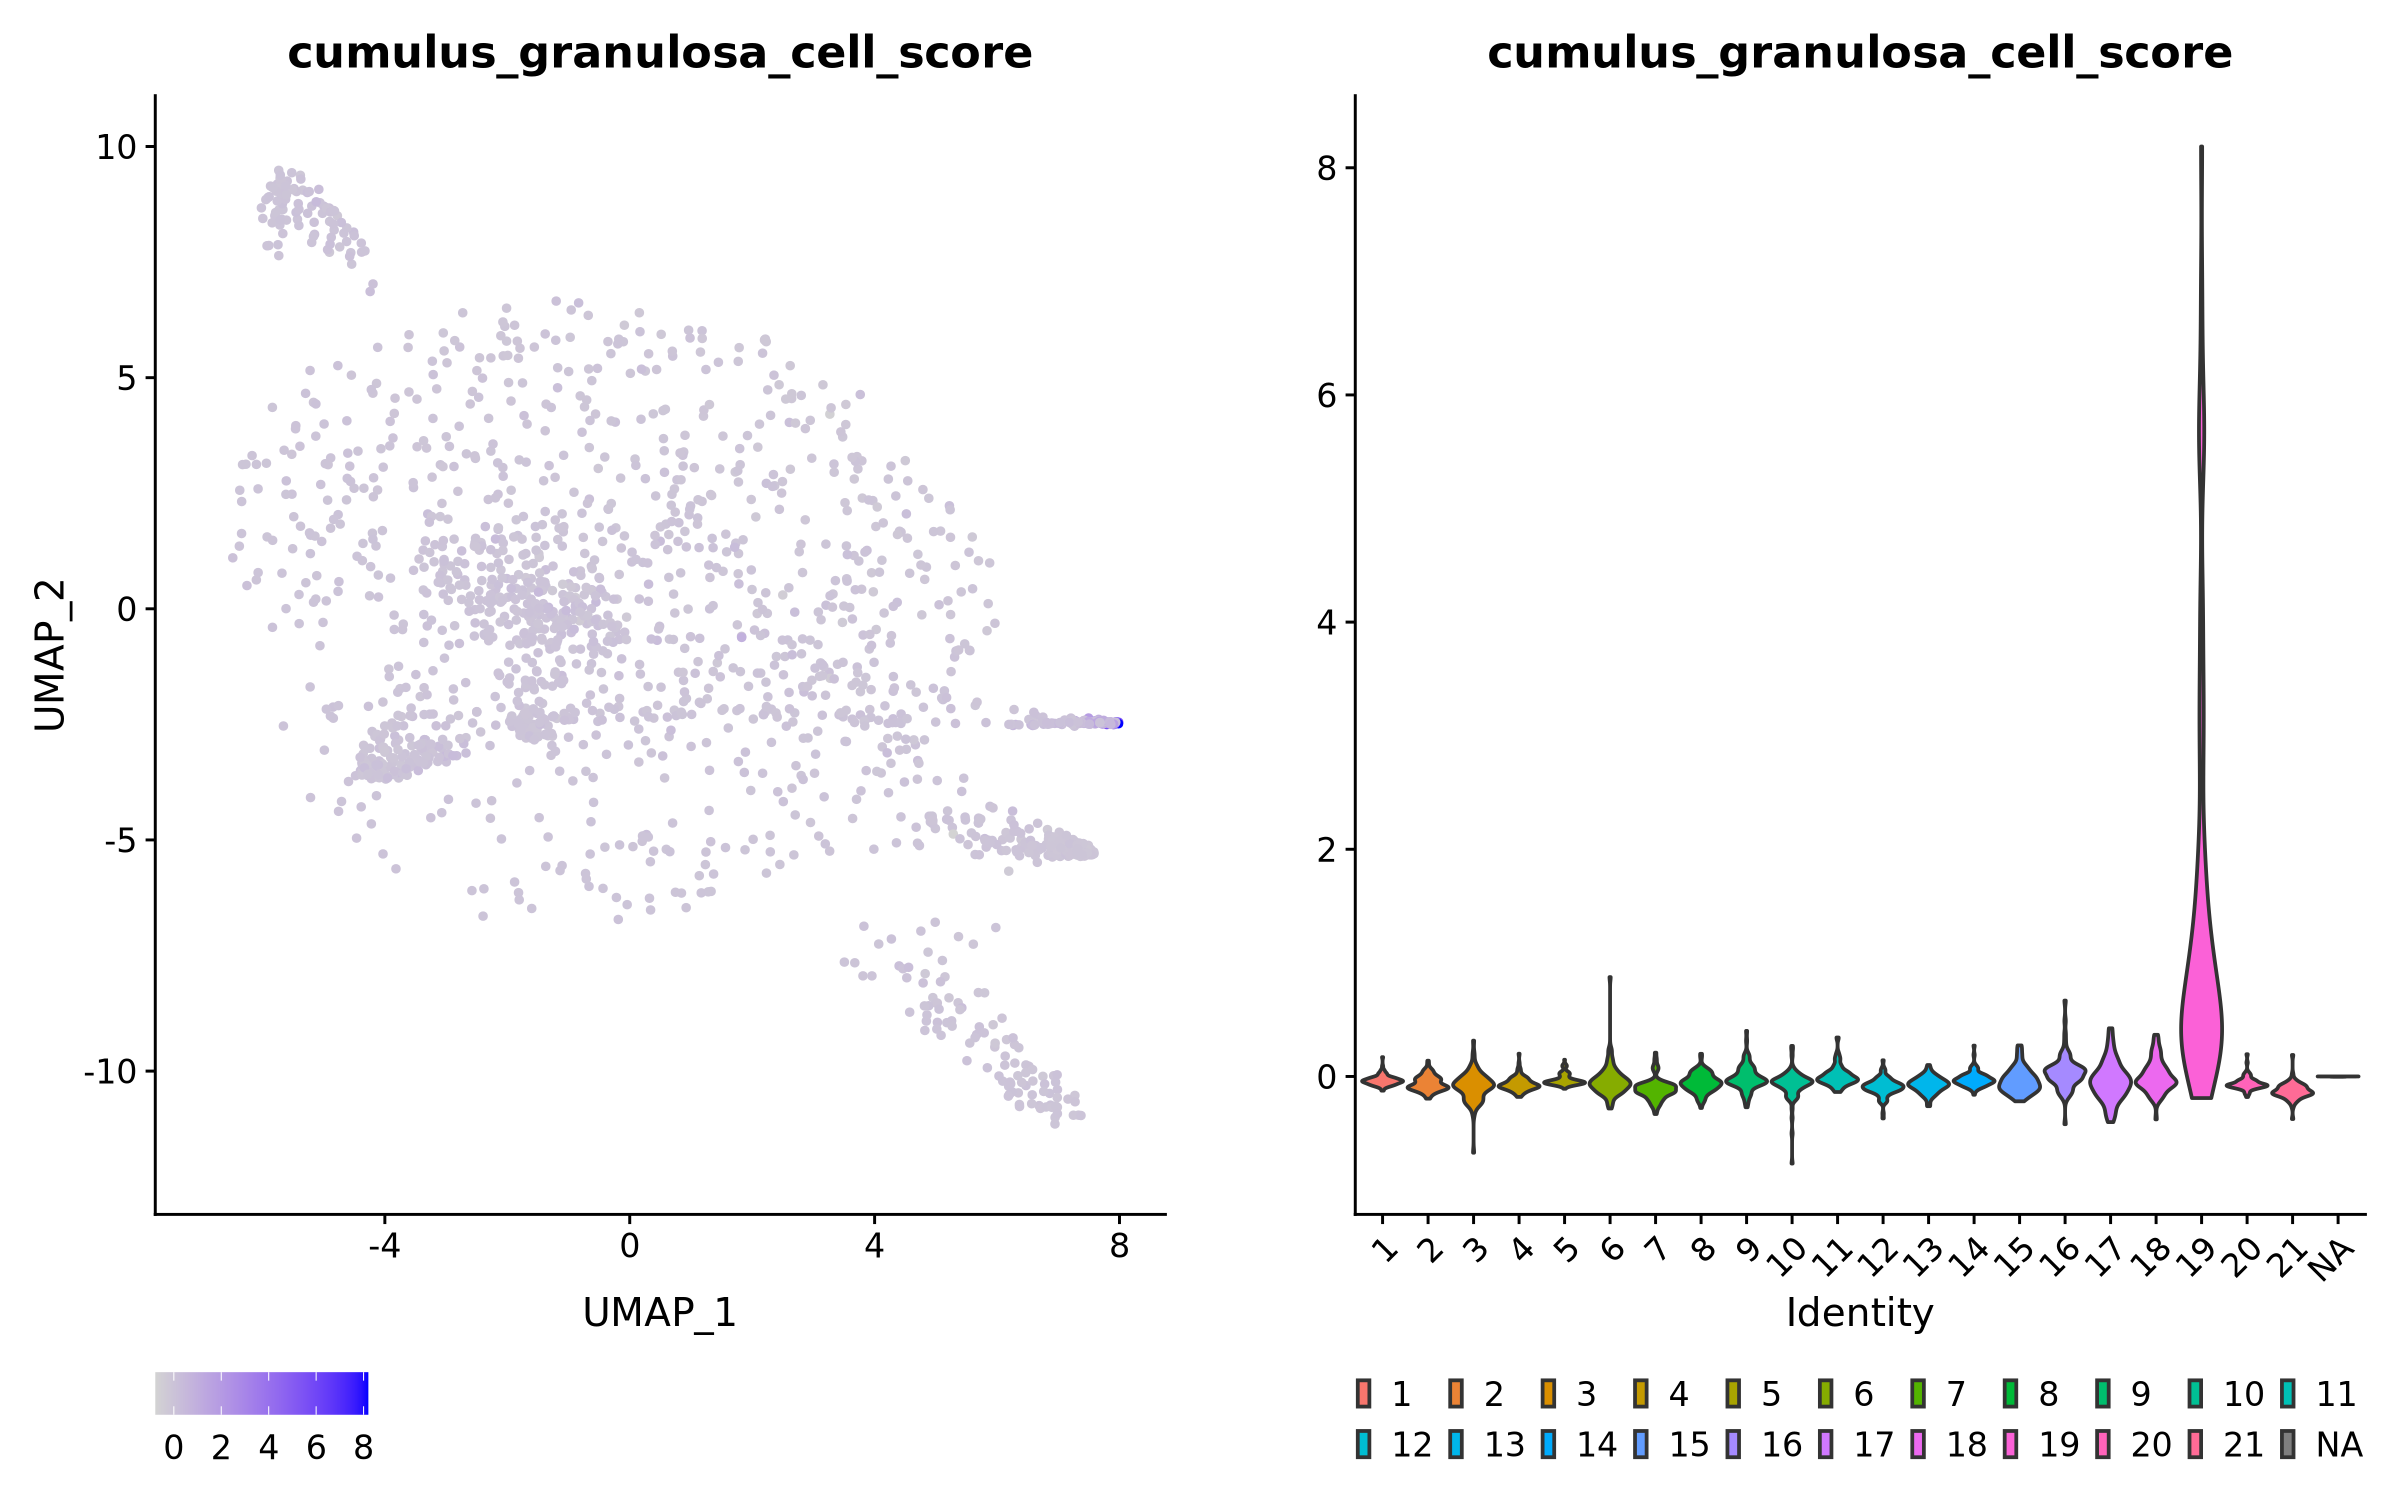

In [23]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "cumulus_granulosa_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "cumulus_granulosa_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

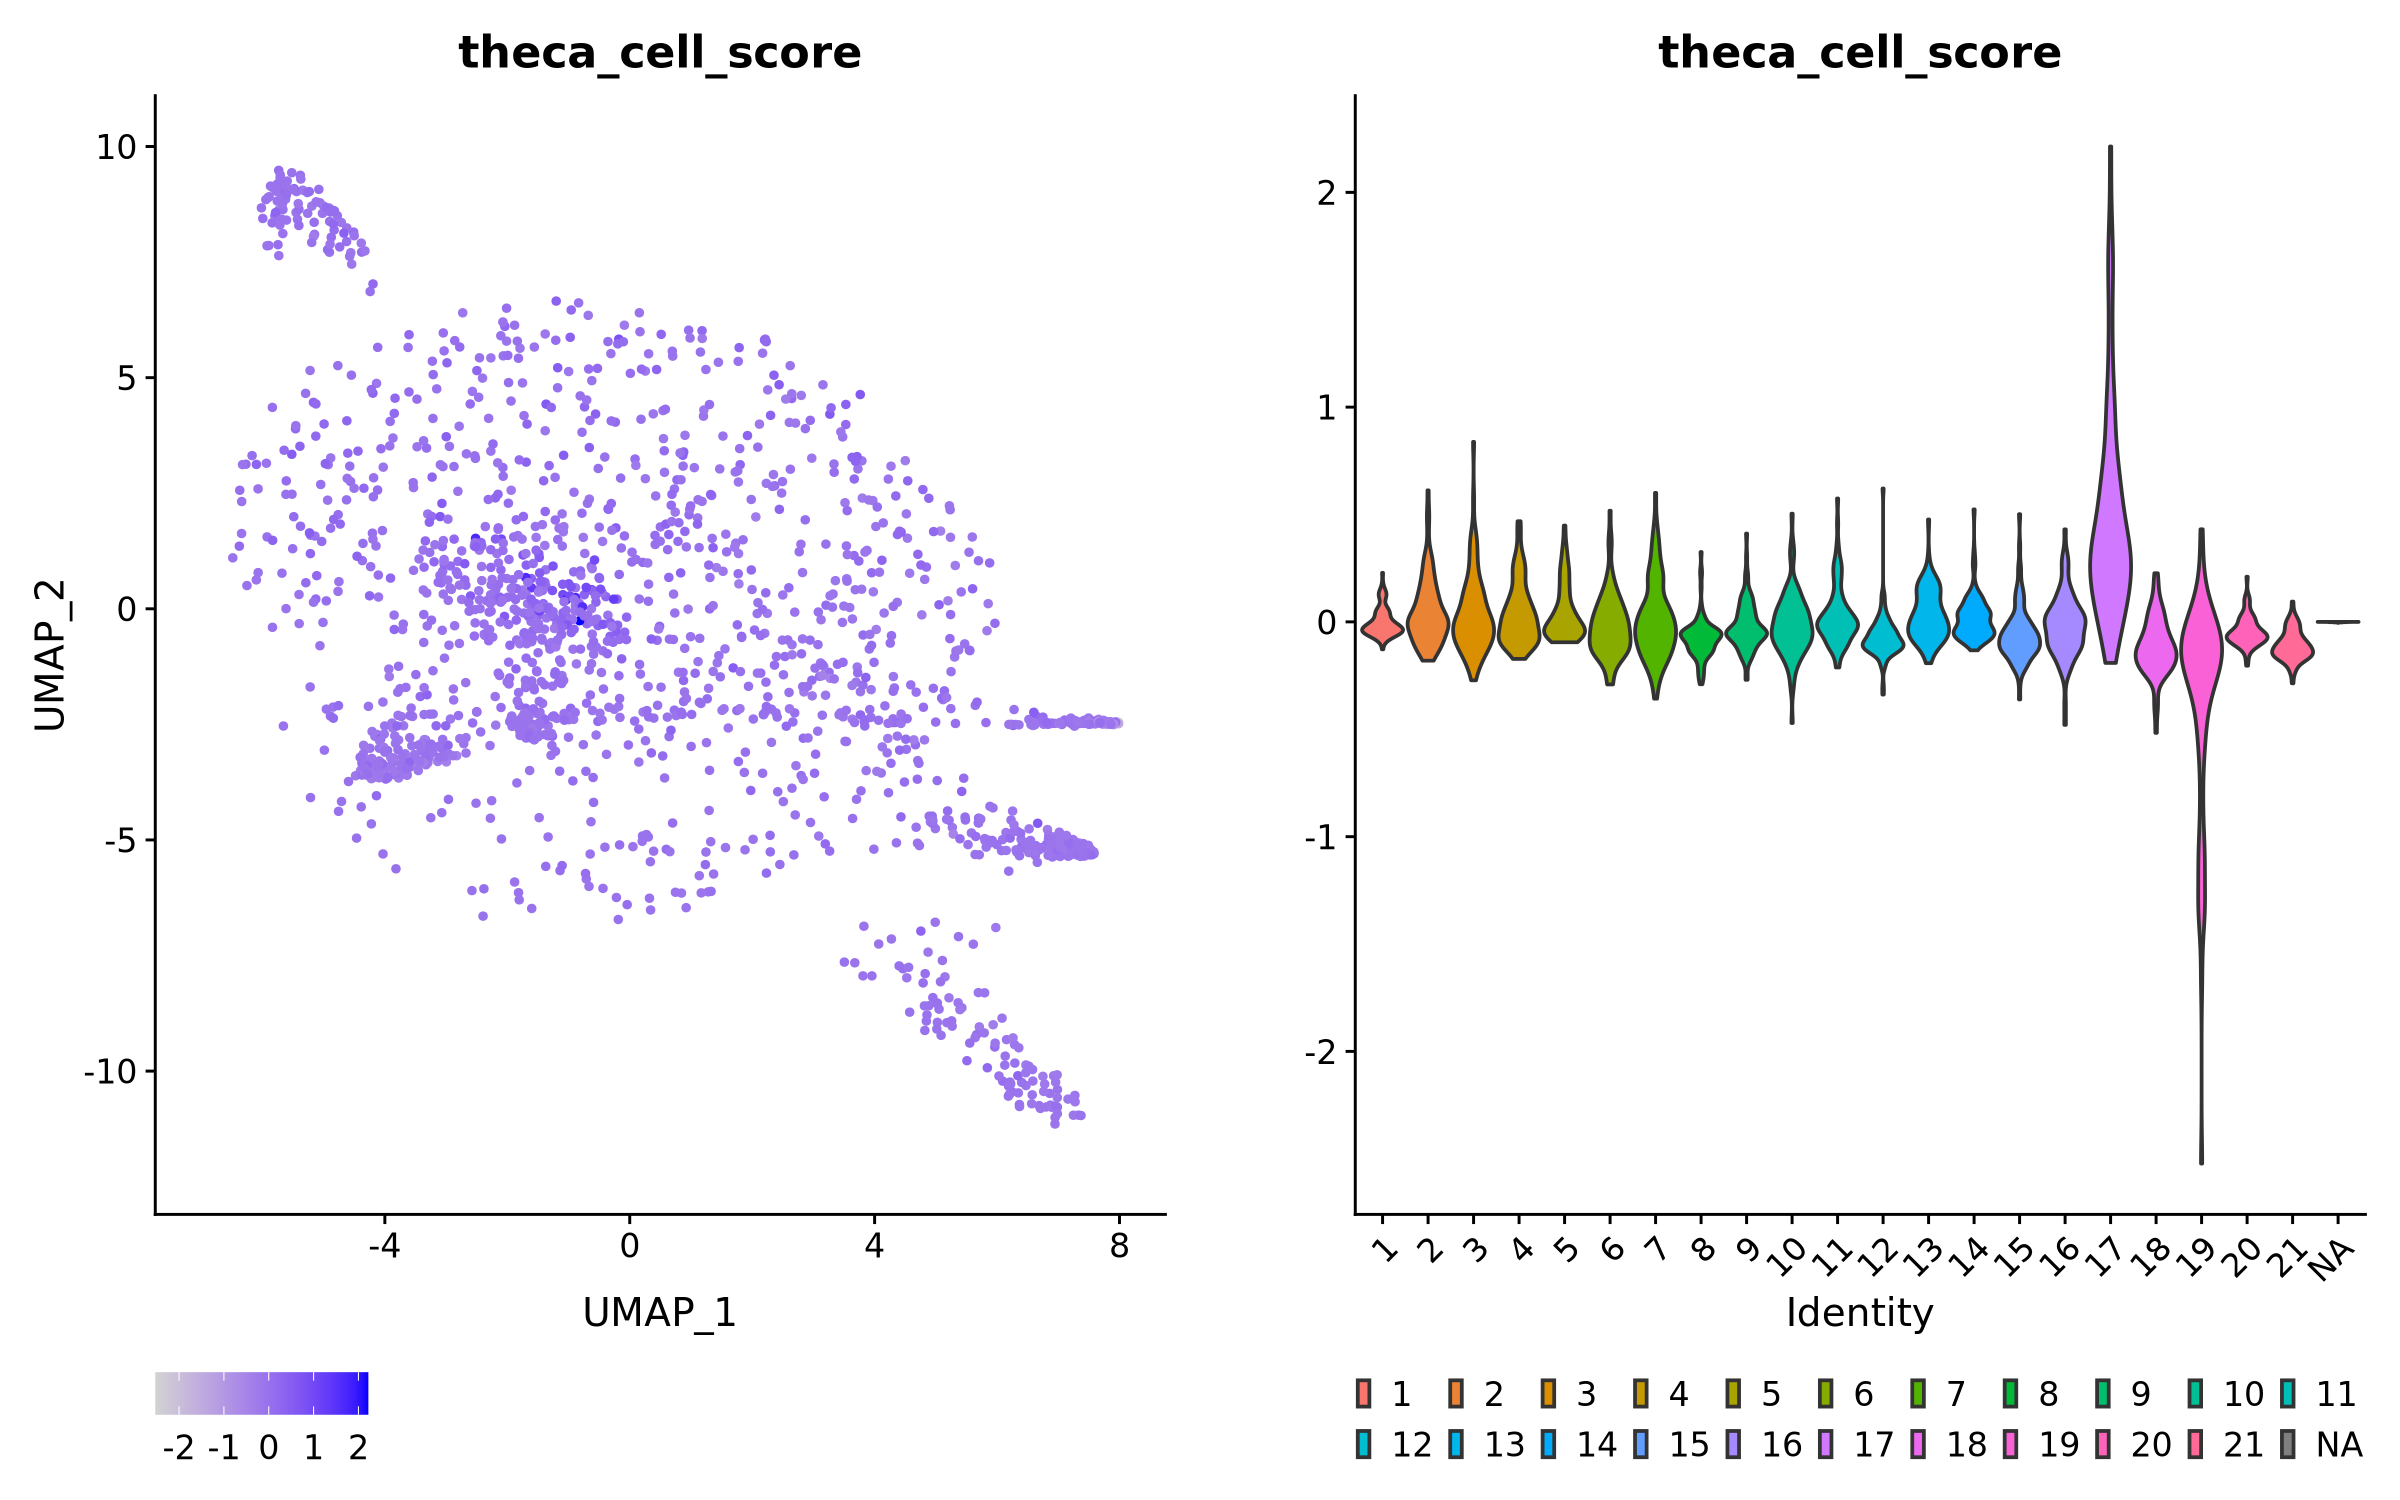

In [24]:
p1 <- FeaturePlot(seurat, reduction = "xenium_umap", features = "theca_cell_score")
p2 <- VlnPlot(object = seurat, group.by = "xenium_clusters", features = "theca_cell_score", pt.size = 0)
plot_grid(
    p1 + theme(legend.position = "bottom"), 
    p2 + theme(legend.position = "bottom", legend.key.size = unit(6, "pt")) + guides(fill=guide_legend(nrow = 2, byrow = TRUE)), 
    align = "vh"
)

In [25]:
first_ten <- rownames(seurat)[1:10]
first_ten

[1] "A2ML1"  "AAMP"   "AAR2"   "AARSD1" "ABAT"   "ABCA1"  "ABCA3"  "ABCA4" 
 [9] "ABCA7"  "ABCB1"

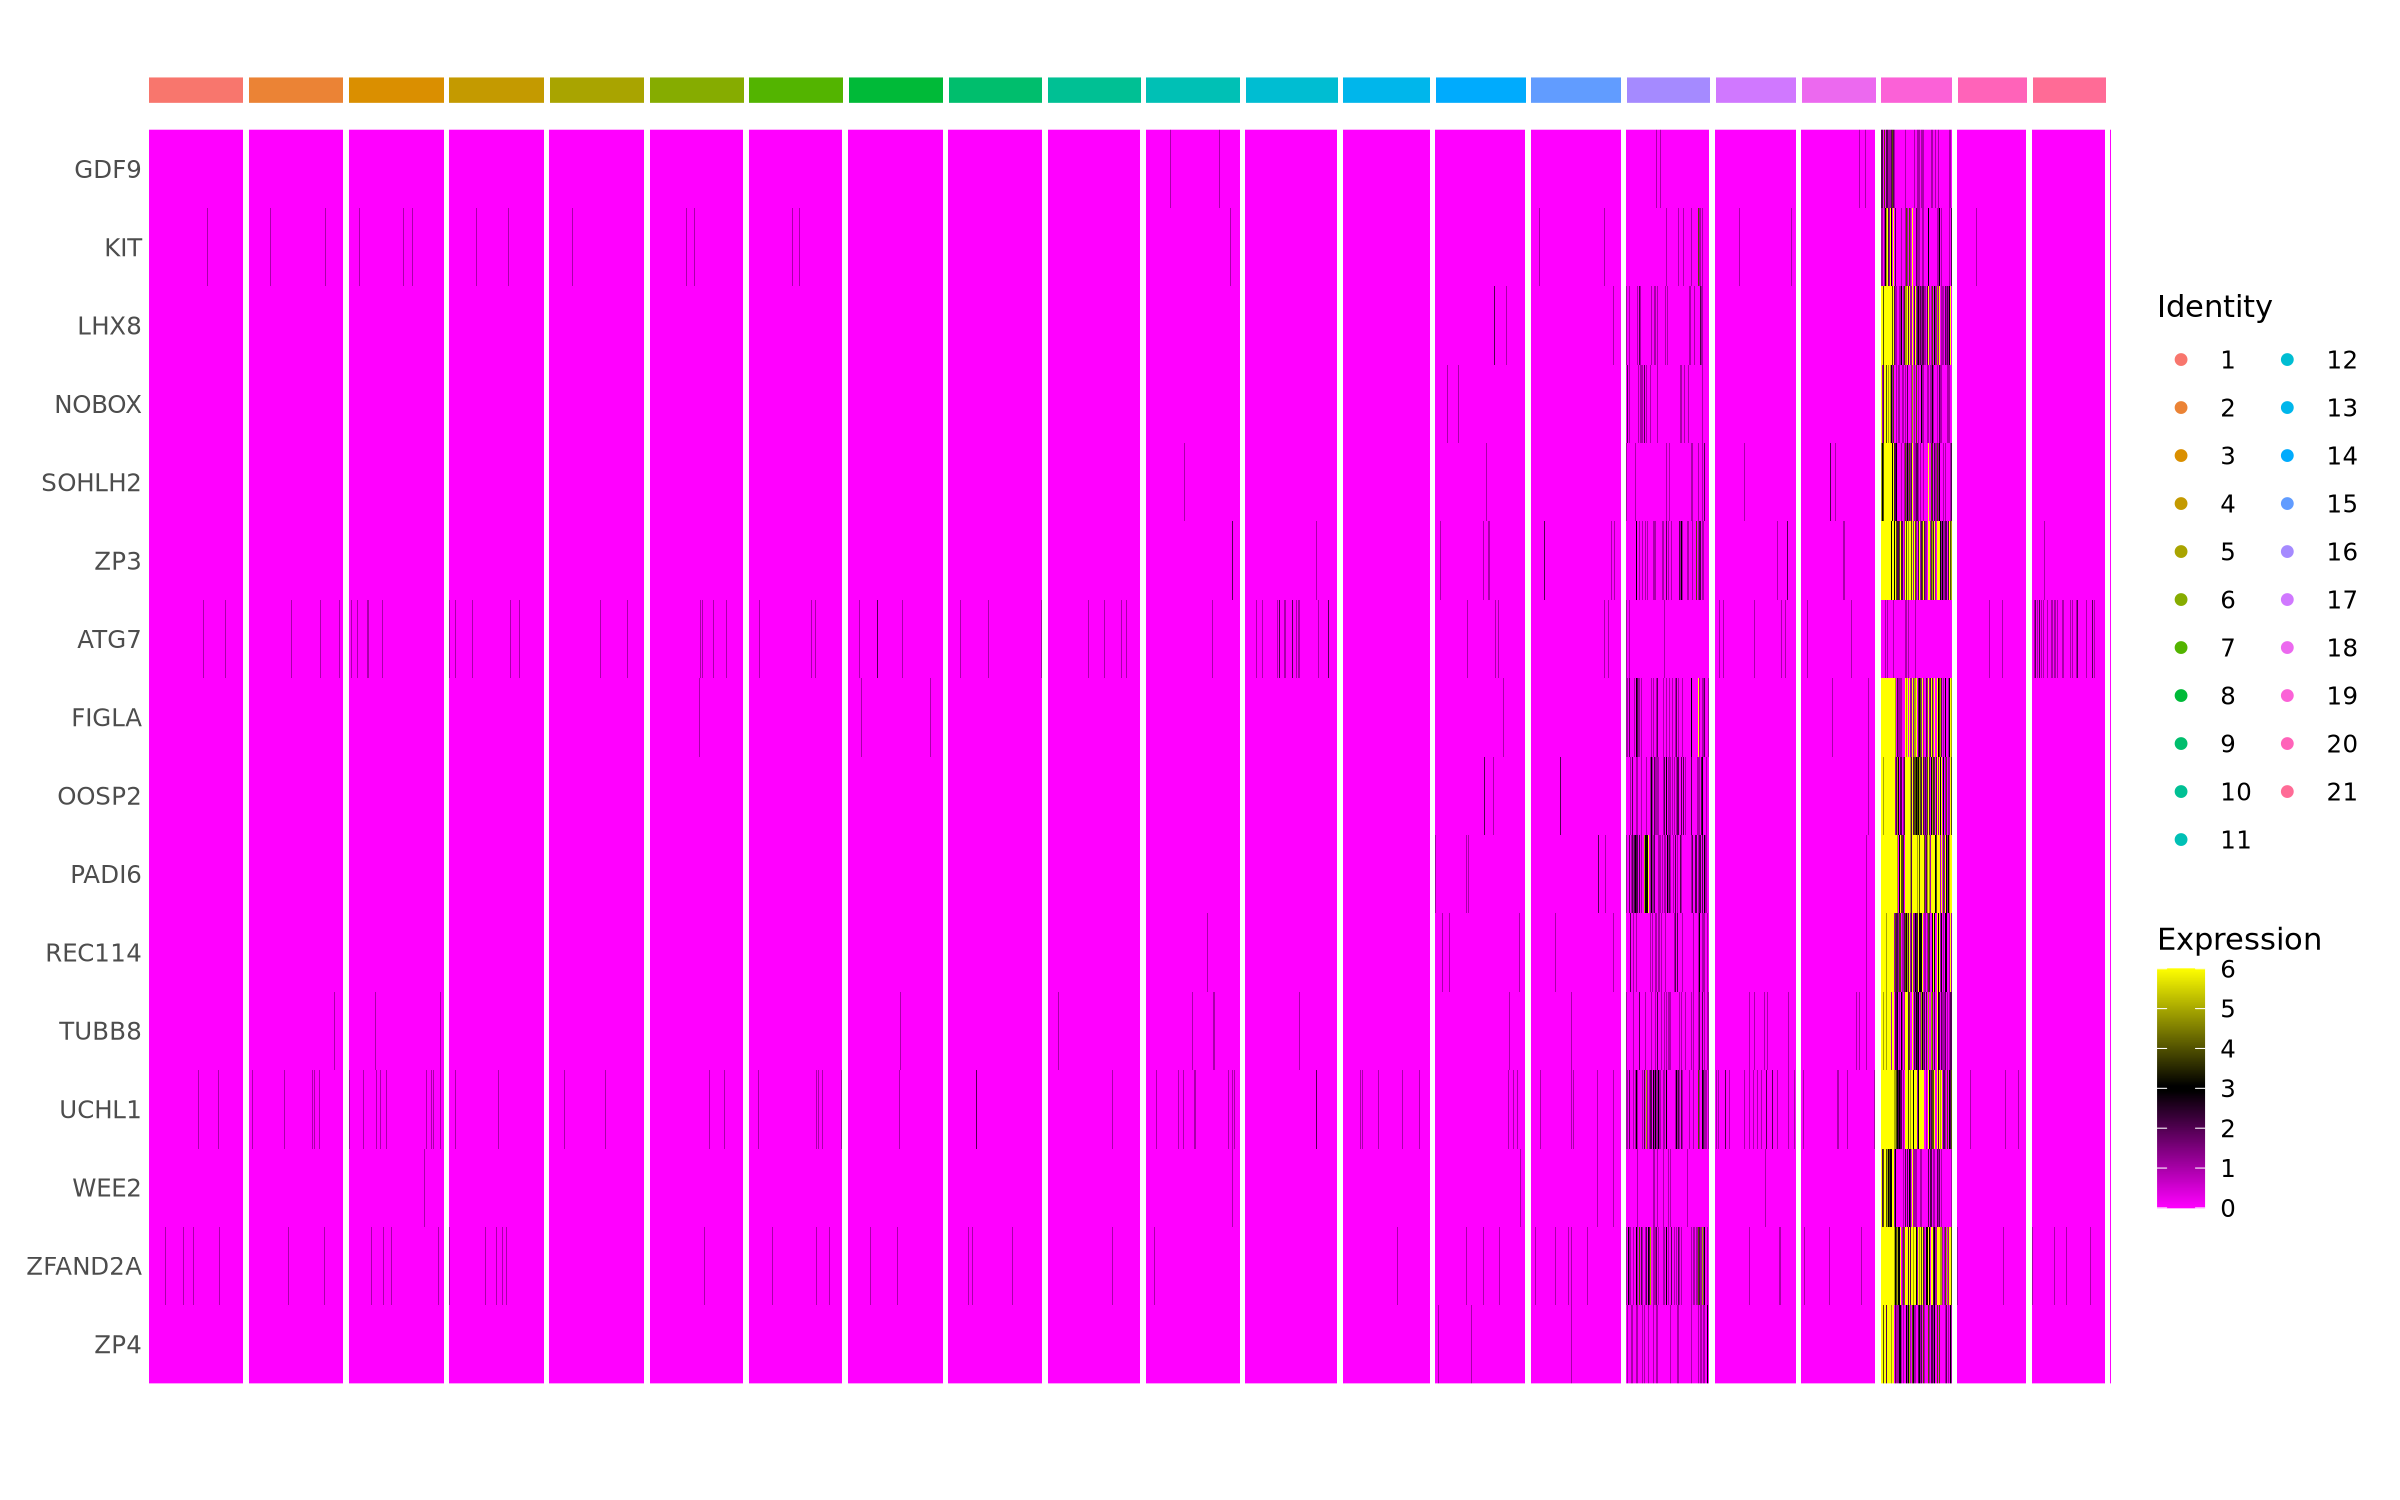

In [26]:
DoHeatmap(object = seurat, features = marker_list$oocyte, slot = "counts", label = FALSE, group.by = "xenium_clusters")

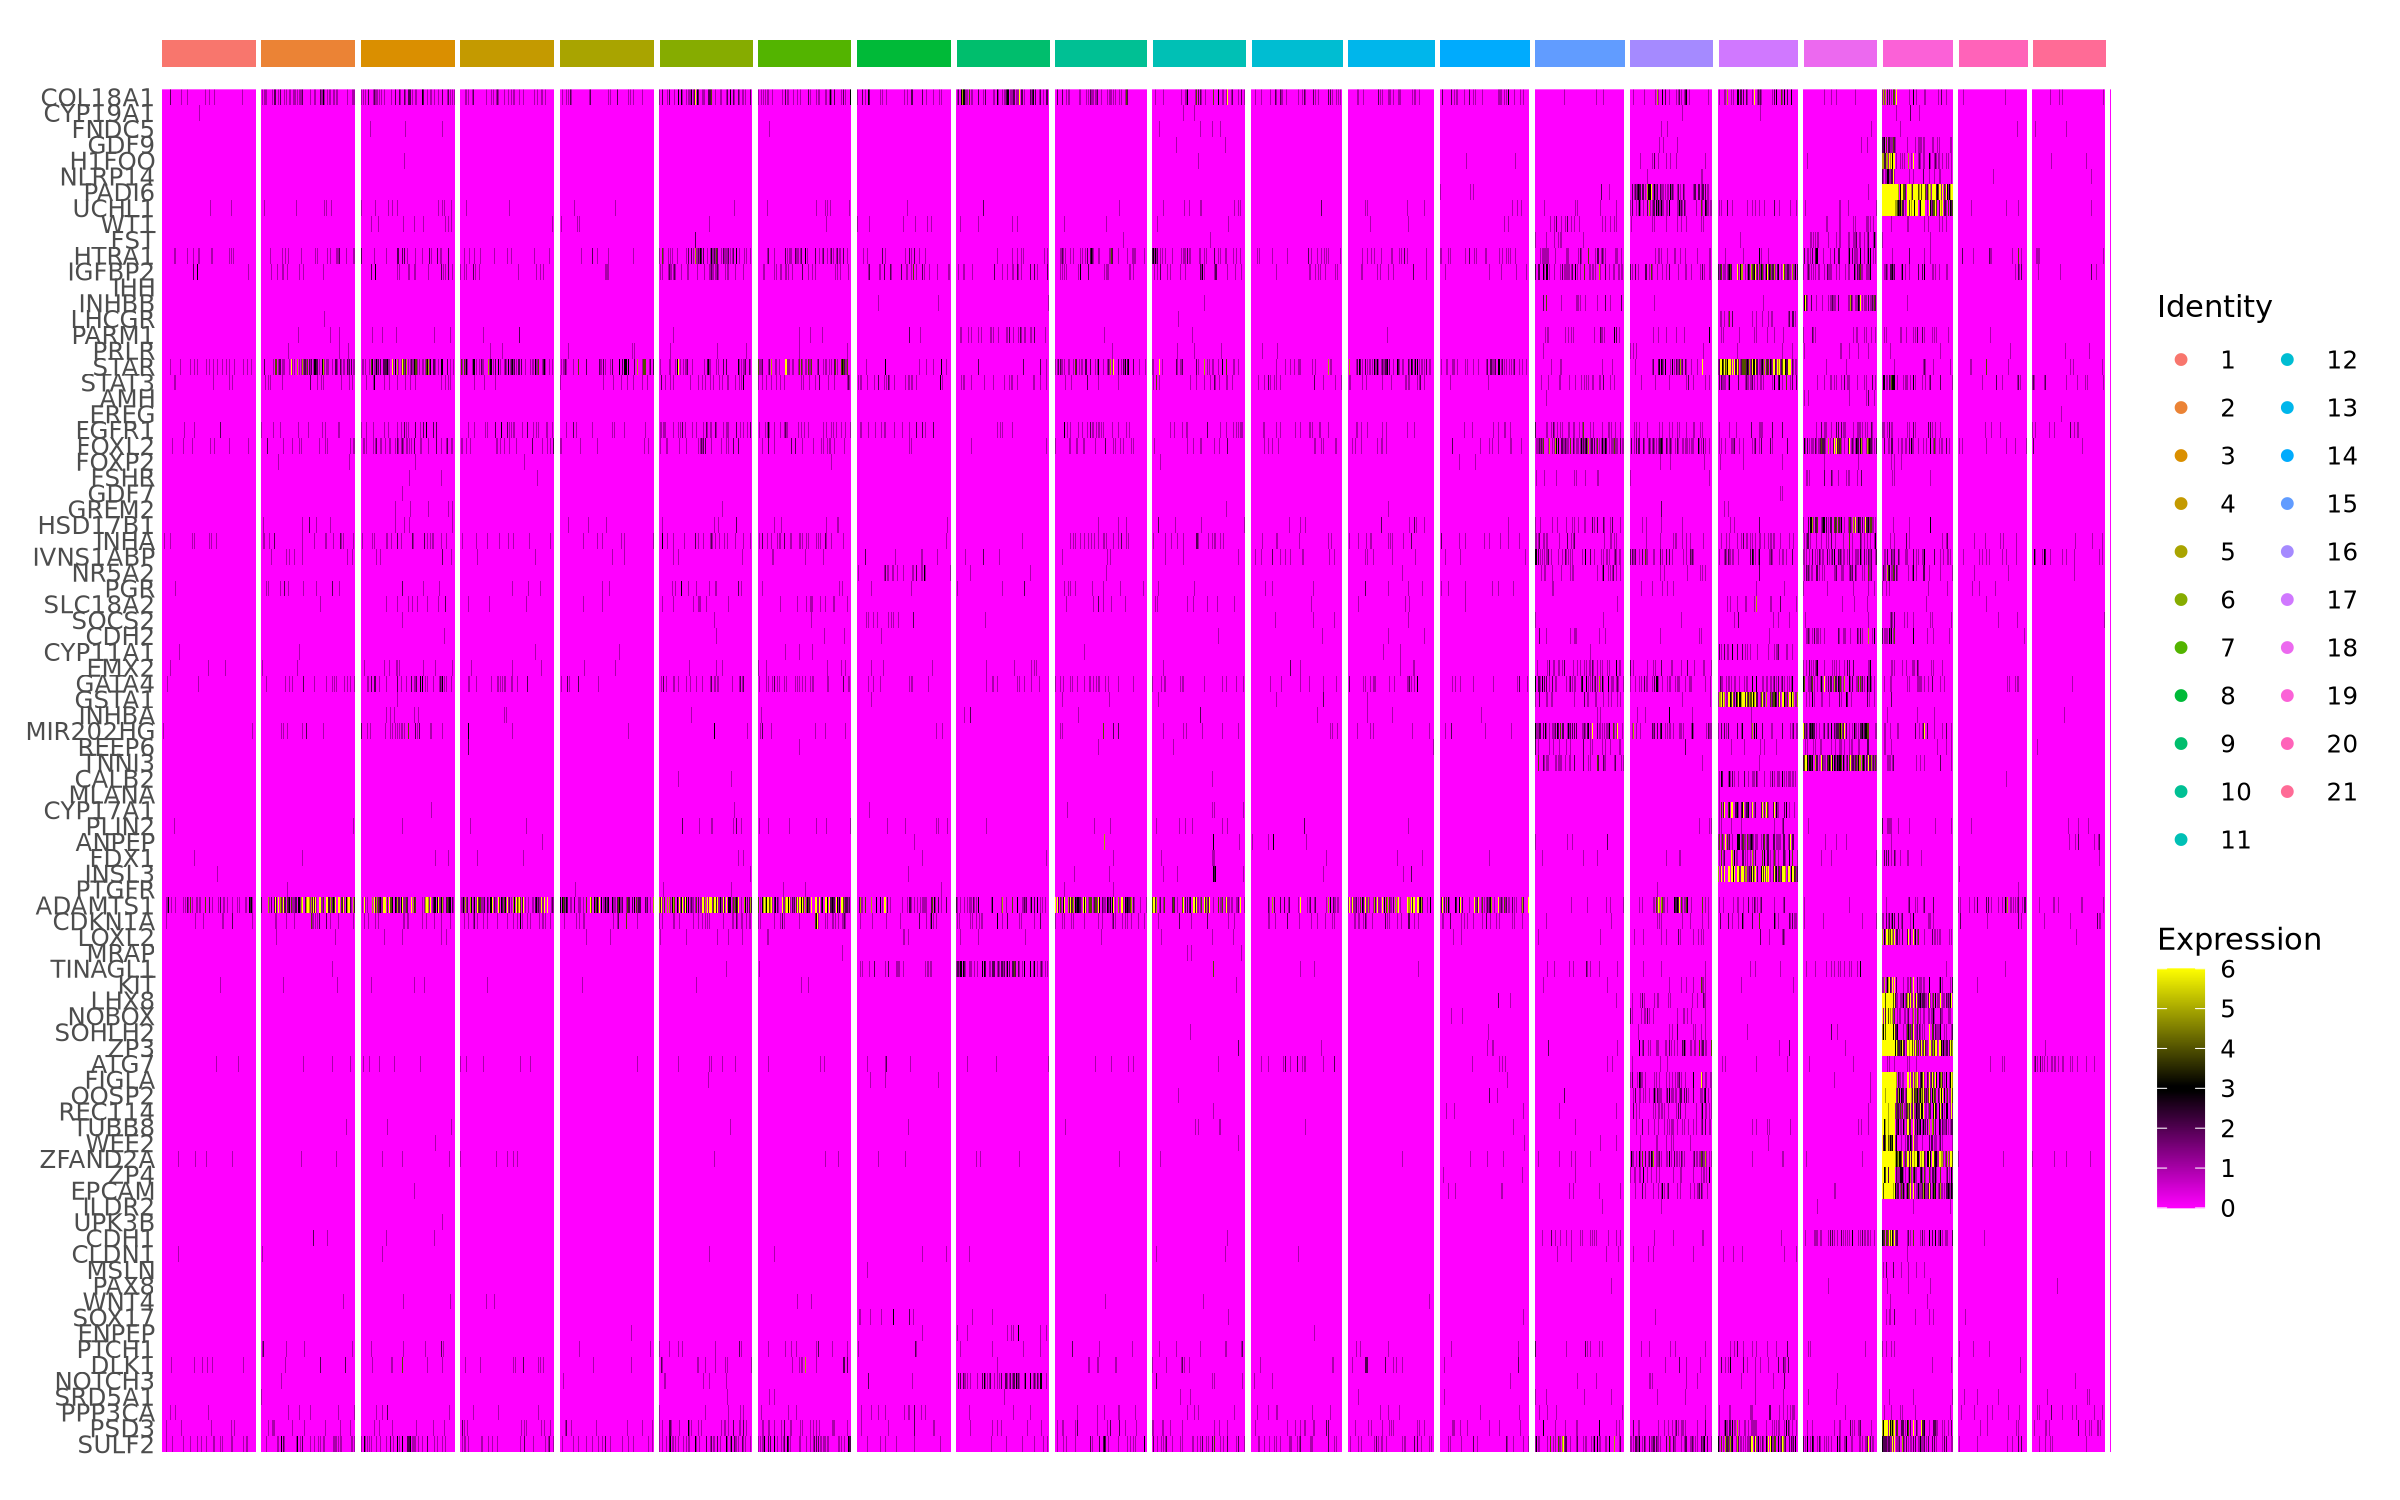

In [27]:
DoHeatmap(object = seurat, features = unlist(marker_list), slot = "counts", label = FALSE, group.by = "xenium_clusters")